# 🔍 Loser Autopsy Notebook

Systematic forensic analysis of trading failures.

```
   Hypothesize          Engineer              Validate
┌────────────┐      ┌────────────────┐    ┌────────────┐
│ "Losers    │ ───▶ │ Add @feature   │ ─▶ │ Re-run     │
│  happen    │      │ in Section 3   │    │ all cells  │
│  when X"   │      │ nothing else   │    │ check AUC  │
└────────────┘      └────────────────┘    └─────┬──────┘
     ▲                                          │
     └──────────────── iterate ─────────────────┘
```

**Workflow:** add one `@feature` function → re-run from Section 4 onward.

## 1. Setup & Data Loading

In [13]:
import sys, os, json, warnings, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi']     = 100
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
ROOT = pathlib.Path('..').resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'backend'))

try:
    notebook_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    notebook_dir = os.getcwd()
project_root = os.path.dirname(notebook_dir)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [14]:
# ── Load positions from strategy backtest output ──────────────────────────────
H5_PATH = '../backend/assets/backtest_results_011.h5'

raw = pd.read_hdf(H5_PATH, 'trades')

_DROP = ['Exit Trade Id', 'Position Id', 'Avg Entry Price', 'Avg Exit Price', 'Size']

training_df = (
    raw
    .rename(columns={
        'Entry Timestamp': 'entry_date',
        'Exit Timestamp':  'exit_date',
        'Return':          'net_return',
    })
    .drop(columns=_DROP, errors='ignore')
    .copy()
)

training_df['entry_date'] = pd.to_datetime(training_df['entry_date']).dt.normalize()
training_df['exit_date']  = pd.to_datetime(training_df['exit_date']).dt.normalize()
training_df = training_df[training_df['entry_date'] >= '2019-01-01'].copy()
training_df['Y']          = (training_df['net_return'] > 0).astype(int)
training_df               = training_df.reset_index(drop=True)

for c in ['symbol', 'entry_date', 'exit_date', 'net_return', 'Y']:
    assert c in training_df.columns, f'Missing required column: {c}'

print(f"Trades   : {len(training_df):,}")
print(f"Date     : {training_df['entry_date'].min().date()} → {training_df['entry_date'].max().date()}")
print(f"Symbols  : {training_df['symbol'].nunique()}")
print(f"Win rate : {training_df['Y'].mean():.2%}  |  Mean return: {training_df['net_return'].mean():.3%}")
print(f"Columns  : {list(training_df.columns)}")

try:
    best_params = pd.read_hdf(H5_PATH, 'best_params')['value'].to_dict()
    print(f"\nStrategy params:")
    for k, v in best_params.items():
        print(f"  {k}: {v}")
except Exception as e:
    best_params = {}
    print(f"\nNo best_params key: {e}")

Trades   : 9,461
Date     : 2019-01-30 → 2026-07-09
Symbols  : 194
Win rate : 32.04%  |  Mean return: 3.924%
Columns  : ['Column', 'entry_date', 'Entry Fees', 'exit_date', 'Exit Fees', 'PnL', 'net_return', 'Direction', 'Status', 'symbol', 'split', 'Y']

Strategy params:
  bb_window: 21.0
  bb_multiplier: 2.0
  kc_window: 21.0
  kc_multiplier: 0.8
  kc_atr_period: 5.0
  low_stop_lookback: 4.0
  atr_period: 17.0
  atr_mult_min: 1.9
  atr_mult_max: 3.7
  corr_window: 15.0
  max_sl: 0.06


In [15]:
# Load price panel once — referenced as `stocks` by all @feature functions
from backend.app.services.data_loader import load_stocks

stocks = None
try:
    df_raw = load_stocks(refresh=False)

    # Drop symbols with >20% missing and forward-fill gaps (same as backtest_005)
    valid_syms = df_raw['close'].columns[df_raw['close'].isna().mean() < 0.2]
    close  = df_raw['close'][valid_syms].ffill()
    open_  = df_raw['open'][valid_syms].ffill()
    high   = df_raw['high'][valid_syms].ffill()
    low    = df_raw['low'][valid_syms].ffill()
    volume = df_raw['volume'][valid_syms].ffill().fillna(0)

    # Reassemble as multi-level DataFrame so stocks['close'] / stocks['open'] etc. work
    stocks = pd.concat(
        {'close': close, 'open': open_, 'high': high, 'low': low, 'volume': volume},
        axis=1,
    )
    print(f'Stocks panel: {stocks.shape}  |  {stocks.index[0].date()} → {stocks.index[-1].date()}')
    print(f'Symbols: {len(valid_syms)}')
except Exception as e:
    print(f'WARNING: Could not load stocks panel: {e}')
    print('  Path, VNINDEX, SMF, and KER features will be skipped.')

Loading from HDF5 cache: stocks_data_latest.h5
Shape: (2500, 985)  |  2016-07-11 → 2026-07-09
Stocks panel: (2500, 985)  |  2016-07-11 → 2026-07-09
Symbols: 197


## 2. Loser Segmentation

Segment by return severity — catastrophic losers need separate treatment.

In [16]:
def segment_trades(df):
    df = df.copy()
    q = df['net_return'].quantile([0.10, 0.30, 0.70, 0.90]).values
    def cat(r):
        if   r <= q[0]: return '1_catastrophic_loss'
        elif r <= q[1]: return '2_medium_loss'
        elif r <= q[2]: return '3_marginal'
        elif r <= q[3]: return '4_medium_win'
        else:           return '5_big_win'
    df['outcome'] = df['net_return'].apply(cat)
    return df, q

training_df, return_quantiles = segment_trades(training_df)
print(f"Thresholds  10%={return_quantiles[0]:.3%}  30%={return_quantiles[1]:.3%}  "
      f"70%={return_quantiles[2]:.3%}  90%={return_quantiles[3]:.3%}")
print(training_df.groupby('outcome').agg(
    count=('net_return','count'), mean=('net_return','mean'), std=('net_return','std'),
).round(4))

Thresholds  10%=-7.422%  30%=-4.741%  70%=1.006%  90%=21.596%
                     count    mean     std
outcome                                   
1_catastrophic_loss    947 -0.0928  0.0176
2_medium_loss         1892 -0.0609  0.0074
3_marginal            3784 -0.0234  0.0143
4_medium_win          1892  0.0898  0.0583
5_big_win              946  0.5210  0.4690


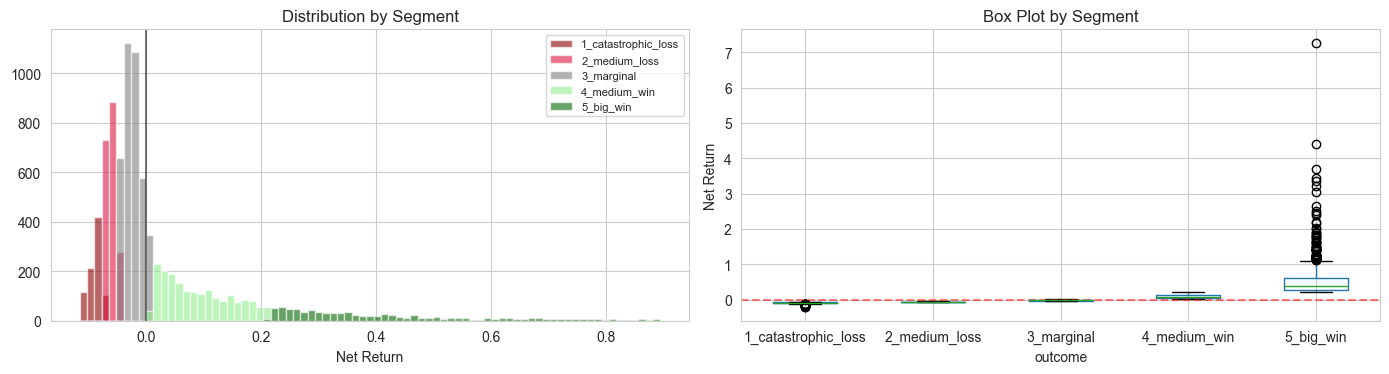

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
bins = np.linspace(training_df['net_return'].quantile(0.01),
                   training_df['net_return'].quantile(0.99), 80)
pal  = {'1_catastrophic_loss':'#8B0000','2_medium_loss':'#DC143C',
        '3_marginal':'#808080','4_medium_win':'#90EE90','5_big_win':'#006400'}
for outcome, color in pal.items():
    axes[0].hist(training_df[training_df['outcome']==outcome]['net_return'],
                 bins=bins, alpha=0.6, label=outcome, color=color)
axes[0].axvline(0, color='black', alpha=0.5)
axes[0].set(xlabel='Net Return', title='Distribution by Segment')
axes[0].legend(fontsize=8)
training_df.boxplot(column='net_return', by='outcome', ax=axes[1], patch_artist=False)
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1].set(title='Box Plot by Segment', ylabel='Net Return')
plt.suptitle(''); plt.tight_layout(); plt.show()

## 3. Feature Registry & Engineering

**This is the only section you edit when testing a new hypothesis.**

| You do | Happens automatically |
|---|---|
| Add `@feature("name", "description")` + function | Appears in §4 discrimination, §10 clustering, §13 export |
| Re-run §3 apply cell + remaining cells | All analysis refreshes with the new column |

**Function contract:**
- Input: `df` — full `training_df`
- Output: `pd.Series` (one column, name = decorator `name`) **or** `pd.DataFrame` (multiple columns)
- Use only data available at `df['entry_date']` — no look-ahead
- `stocks` is a notebook global (loaded in §1)

In [18]:
# Registry — populated by @feature decorator
FEATURES: dict = {}

def feature(name: str, description: str = ''):
    """Register a feature function.
    fn(df) -> pd.Series   : adds one column named `name`
    fn(df) -> pd.DataFrame: adds all columns in the returned DataFrame
    """
    def decorator(fn):
        FEATURES[name] = {'fn': fn, 'description': description or name}
        return fn
    return decorator

print('Feature registry ready.')

Feature registry ready.


In [19]:
# ── Built-in: VNINDEX regime features ─────────────────────────────────────────

@feature('vnindex_features', 'VNINDEX momentum, trend, drawdown, volatility at entry')
def _(df):
    COLS = ['vnindex_ret_5d','vnindex_ret_20d','vnindex_above_ema50',
            'vnindex_above_ema200','vnindex_drawdown','vnindex_vol_20d']
    if stocks is None or 'VNINDEX' not in stocks['close'].columns:
        return pd.DataFrame({c: np.nan for c in COLS}, index=df.index)
    vix     = stocks['close']['VNINDEX'].dropna()
    vix_r5  = vix.pct_change(5)
    vix_r20 = vix.pct_change(20)
    vix_e50 = vix.rolling(50).mean()
    vix_e2  = vix.rolling(200).mean()
    vix_dd  = vix / vix.rolling(252).max() - 1
    vix_vol = vix.pct_change().rolling(20).std()
    def _at(s, t):
        try:    return float(s.loc[:t].iloc[-1])
        except: return np.nan
    rows = []
    for t in df['entry_date']:
        t = pd.Timestamp(t).normalize()
        v, e50, e200 = _at(vix,t), _at(vix_e50,t), _at(vix_e2,t)
        rows.append({
            'vnindex_ret_5d':       _at(vix_r5, t),
            'vnindex_ret_20d':      _at(vix_r20, t),
            'vnindex_above_ema50':  int(v>e50)  if not any(np.isnan([v,e50]))  else np.nan,
            'vnindex_above_ema200': int(v>e200) if not any(np.isnan([v,e200])) else np.nan,
            'vnindex_drawdown':     _at(vix_dd,  t),
            'vnindex_vol_20d':      _at(vix_vol, t),
        })
    return pd.DataFrame(rows, index=df.index)

In [20]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  ✏️  ADD YOUR HYPOTHESIS HERE                                           ║
# ║                                                                          ║
# ║  1. Write a @feature function below                                     ║
# ║  2. Re-run this cell + the _apply_all cell below                        ║
# ║  3. Re-run §4 onward — your feature appears automatically               ║
# ║                                                                          ║
# ║  Available globals: df, stocks, stocks['close']['VNINDEX']              ║
# ╚══════════════════════════════════════════════════════════════════════════╝

# ─── Hypothesis: buying near the 52w high fails more (overextended entries) ───
@feature('dist_from_52w_high', 'close/52w-max − 1 at entry  (0=at peak, negative=below)')
def _(df):
    if stocks is None:
        return pd.Series(np.nan, index=df.index)
    cp = stocks['close']
    result = []
    for _, row in df.iterrows():
        sym = row['symbol']
        t   = pd.Timestamp(row['entry_date']).normalize()
        if sym not in cp.columns:
            result.append(np.nan); continue
        past = cp[sym].loc[:t].dropna().tail(252)
        result.append(float(past.iloc[-1] / past.max() - 1) if len(past) else np.nan)
    return pd.Series(result, index=df.index)


# ─── Hypothesis: low-volume breakouts fail more ───────────────────────────────
@feature('breakout_vol_ratio', 'entry volume / 20d avg volume  (>1 = confirmed)')
def _(df):
    if stocks is None or 'volume' not in stocks:
        return pd.Series(np.nan, index=df.index)
    vol = stocks['volume']
    result = []
    for _, row in df.iterrows():
        sym = row['symbol']
        t   = pd.Timestamp(row['entry_date']).normalize()
        if sym not in vol.columns:
            result.append(np.nan); continue
        s = vol[sym].loc[:t].dropna()
        if len(s) < 20:
            result.append(np.nan); continue
        entry_vol = float(s.iloc[-1])
        ma20 = float(s.tail(20).mean())
        result.append(entry_vol / ma20 if ma20 else np.nan)
    return pd.Series(result, index=df.index)


# ─── Hypothesis: weak intraday close signals failure ─────────────────────────
@feature('close_in_range', '(close−low)/(high−low)  — 1=top of range, 0=bottom')
def _(df):
    if stocks is None or 'close' not in stocks or 'high' not in stocks or 'low' not in stocks:
        return pd.Series(np.nan, index=df.index)
    cp, hi, lo = stocks['close'], stocks['high'], stocks['low']
    result = []
    for _, row in df.iterrows():
        sym = row['symbol']
        t   = pd.Timestamp(row['entry_date']).normalize()
        if sym not in cp.columns or sym not in hi.columns or sym not in lo.columns:
            result.append(np.nan); continue
        try:
            c = float(cp[sym].loc[:t].dropna().iloc[-1])
            h = float(hi[sym].loc[:t].dropna().iloc[-1])
            l = float(lo[sym].loc[:t].dropna().iloc[-1])
        except IndexError:
            result.append(np.nan); continue
        result.append((c - l) / (h - l + 1e-9))
    return pd.Series(result, index=df.index)


print(f"Registered {len(FEATURES)} features: {list(FEATURES.keys())}")

Registered 4 features: ['vnindex_features', 'dist_from_52w_high', 'breakout_vol_ratio', 'close_in_range']


In [21]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  Regime & Autocorrelation Features                                       ║
# ║                                                                          ║
# ║  Hypothesis: entries during chop (low KER), bearish SMF, or             ║
# ║  mean-reverting autocorrelation fail more than trend-aligned entries.   ║
# ╚══════════════════════════════════════════════════════════════════════════╝

from backend.app.services.indicators.smart_money_flow import smart_money_flow_cloud, SMF_DEFAULTS


# ─── Autocorrelation helper ────────────────────────────────────────────────────
def _autocorr_nd(df, n_days: int, lookback: int = 120):
    """Lag-1 autocorrelation of n-day returns in a rolling lookback window at entry."""
    if stocks is None:
        return pd.Series(np.nan, index=df.index, name=f'autocorr_{n_days}d')
    cp = stocks['close'].copy()
    cp.index = pd.DatetimeIndex(cp.index).normalize()
    result = []
    min_obs = max(15, n_days * 3)
    for _, row in df.iterrows():
        sym = row['symbol']
        t   = pd.Timestamp(row['entry_date']).normalize()
        if sym not in cp.columns:
            result.append(np.nan); continue
        past = cp[sym].loc[:t].dropna().tail(lookback + n_days)
        ret  = past.pct_change(n_days).dropna().iloc[-lookback:]
        result.append(float(ret.autocorr(lag=1)) if len(ret) >= min_obs else np.nan)
    return pd.Series(result, index=df.index, name=f'autocorr_{n_days}d')


@feature('autocorr_5d',
         'lag-1 autocorr of 5d returns, 120-bar window at entry (>0=trending, <0=mean-rev)')
def _(df): return _autocorr_nd(df, n_days=5)

@feature('autocorr_10d',
         'lag-1 autocorr of 10d returns, 120-bar window at entry (>0=trending, <0=mean-rev)')
def _(df): return _autocorr_nd(df, n_days=10)

@feature('autocorr_20d',
         'lag-1 autocorr of 20d returns, 120-bar window at entry (>0=trending, <0=mean-rev)')
def _(df): return _autocorr_nd(df, n_days=20)


# ─── 2. Smart Money Flow regime gate at entry ─────────────────────────────────
# last_signal: +1 = bull, -1 = bear
# strength_signed: signed tanh of trend strength (-1 to +1)
@feature('smf_regime',
         'SMF last_signal (+1=bull/-1=bear) and strength_signed at entry')
def _(df):
    COLS = ['smf_signal', 'smf_strength']
    if stocks is None or 'open' not in stocks or 'volume' not in stocks:
        return pd.DataFrame({c: np.nan for c in COLS}, index=df.index)

    syms = [s for s in df['symbol'].unique() if s in stocks['close'].columns]
    if not syms:
        return pd.DataFrame({c: np.nan for c in COLS}, index=df.index)

    smf_cache = {}
    try:
        raw = smart_money_flow_cloud(
            stocks['open'][syms],   stocks['high'][syms],
            stocks['low'][syms],    stocks['close'][syms],
            stocks['volume'][syms], **SMF_DEFAULTS,
        )
        for sym in syms:
            # raw[sym] is {field: Series} — convert to DataFrame first
            s = pd.DataFrame(raw[sym])
            s.index = pd.DatetimeIndex(s.index).normalize()
            smf_cache[sym] = s
    except Exception as e:
        print(f'  SMF compute error: {e}')
        return pd.DataFrame({c: np.nan for c in COLS}, index=df.index)

    sig_list, str_list = [], []
    for _, row in df.iterrows():
        sym = row['symbol']
        t   = pd.Timestamp(row['entry_date']).normalize()
        if sym not in smf_cache:
            sig_list.append(np.nan); str_list.append(np.nan); continue
        s   = smf_cache[sym]
        loc = s.index.get_indexer([t], method='ffill')[0]
        if loc < 0:
            sig_list.append(np.nan); str_list.append(np.nan)
        else:
            sig_list.append(float(s['last_signal'].iloc[loc]))
            str_list.append(float(s['strength_signed'].iloc[loc]))
    # return pd.Series(sig_list, index=df.index, name=f'smf_signal')
    return pd.DataFrame({'smf_signal': sig_list, 'smf_strength': str_list}, index=df.index)


# ─── 3. KER Gate at entry ─────────────────────────────────────────────────────
@feature('ker_gate',
         'KER gate_open (1=trend,0=chop) and pct_rank at entry — Daily preset')
def _(df):
    COLS = ['ker_gate_open', 'ker_pct_rank']
    if stocks is None:
        return pd.DataFrame({c: np.nan for c in COLS}, index=df.index)

    cp = stocks['close'].copy()
    cp.index = pd.DatetimeIndex(cp.index).normalize()
    syms = [s for s in df['symbol'].unique() if s in cp.columns]

    ER_LEN, SMOOTH_LEN, RANK_WIN, STABILITY = 10, 2, 50, 10
    enter_pct = 50.0 + STABILITY / 2.0
    exit_pct  = 50.0 - STABILITY / 2.0
    alpha     = 2.0 / (SMOOTH_LEN + 1)

    ker_cache = {}
    for sym in syms:
        price = cp[sym].dropna()
        n     = len(price)
        if n < RANK_WIN + ER_LEN + 10:
            continue
        c = price.values.astype(np.float64)

        direction = np.full(n, np.nan)
        direction[ER_LEN:] = np.abs(c[ER_LEN:] - c[:n - ER_LEN])
        abs_ret = np.zeros(n); abs_ret[1:] = np.abs(np.diff(c))
        cum = np.cumsum(abs_ret)
        vol = np.full(n, np.nan)
        vol[ER_LEN:] = cum[ER_LEN:] - cum[:n - ER_LEN]
        with np.errstate(divide='ignore', invalid='ignore'):
            ker_raw = np.where((vol > 0) & ~np.isnan(direction), direction / vol, 0.0)

        ker_s = np.zeros(n); ker_s[0] = ker_raw[0]
        for i in range(1, n):
            ker_s[i] = alpha * ker_raw[i] + (1 - alpha) * ker_s[i - 1]

        pct_rank = np.full(n, 50.0)
        for i in range(RANK_WIN, n):
            win = ker_s[i - RANK_WIN + 1 : i + 1]
            pct_rank[i] = np.sum(win < ker_s[i]) / RANK_WIN * 100.0

        gate = np.zeros(n, dtype=bool); state = False
        for i in range(1, n):
            r = pct_rank[i]
            if not state and r >= enter_pct: state = True
            elif state and r <= exit_pct:    state = False
            gate[i] = state

        ker_cache[sym] = pd.DataFrame(
            {'gate_open': gate, 'pct_rank': pct_rank}, index=price.index
        )

    gate_list, rank_list = [], []
    for _, row in df.iterrows():
        sym = row['symbol']
        t   = pd.Timestamp(row['entry_date']).normalize()
        if sym not in ker_cache:
            gate_list.append(np.nan); rank_list.append(np.nan); continue
        sig = ker_cache[sym]
        loc = sig.index.get_indexer([t], method='ffill')[0]
        if loc < 0:
            gate_list.append(np.nan); rank_list.append(np.nan)
        else:
            gate_list.append(float(sig['gate_open'].iloc[loc]))
            rank_list.append(float(sig['pct_rank'].iloc[loc]))

    # return pd.Series(gate_list, index=df.index, name=f'ker_gate_open')
    return pd.DataFrame({'ker_gate_open': gate_list, 'ker_pct_rank': rank_list}, index=df.index)


print(f"Registered {len(FEATURES)} features: {list(FEATURES.keys())}")

{'v1': {'bb_window': 23, 'bb_multiplier': 1.5, 'bb_matype': 2, 'kc_window': 21, 'kc_multiplier': 0.9, 'kc_atr_period': 5, 'donichan_window': 11, 'osc_smoothing_period': 9, 'low_stop_lookback': 5, 'atr_period': 10, 'atr_multiplier': 1.9, 'max_sl': 0.06}, 'v2': {'bb_window': 22, 'bb_multiplier': 2.0, 'bb_matype': 0, 'kc_window': 16, 'kc_multiplier': 0.8, 'kc_atr_period': 13, 'donichan_window': 11, 'osc_smoothing_period': 8, 'low_stop_lookback': 5, 'atr_period': 10, 'atr_multiplier': 2.2, 'max_sl': 0.07}, 'v3': {'bb_window': 11, 'bb_multiplier': 0.9, 'bb_matype': 0, 'kc_window': 20, 'kc_multiplier': 1.9000000000000001, 'kc_atr_period': 19, 'donichan_window': 11, 'osc_smoothing_period': 9, 'low_stop_lookback': 3, 'atr_period': 5, 'atr_multiplier': 3.5, 'max_sl': 0.14, 'william_vix_period': 18, 'consecutive_neg_threshold': 4}}
Registered 9 features: ['vnindex_features', 'dist_from_52w_high', 'breakout_vol_ratio', 'close_in_range', 'autocorr_5d', 'autocorr_10d', 'autocorr_20d', 'smf_regime',

In [22]:
# ── 2-State Walk-Forward HMM Regime Features (Market + Symbol) ───────────────
# Mirrors backtest_005_hmm_regime.ipynb — zero lookahead, retrained every 5 bars.
#
# Features added to training_df:
#   hmm_market_regime  : 1=Risk-On  0=Risk-Off  (VNINDEX HMM at entry date)
#   hmm_symbol_regime  : 1=Risk-On  0=Risk-Off  (per-symbol HMM at entry date)

from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler

_HMM_W            = 20     # rolling window for volatility / momentum / vol_ratio
_HMM_BURN_IN      = 252    # minimum bars before first prediction
_HMM_RETRAIN_EVERY = 5     # re-fit every N bars (same as backtest_005_hmm_regime)
_HMM_SEED         = 42


def _build_wf_hmm(price: 'pd.Series', volume: 'pd.Series',
                  W=_HMM_W, burn_in=_HMM_BURN_IN,
                  retrain_every=_HMM_RETRAIN_EVERY, seed=_HMM_SEED) -> 'pd.Series':
    """
    Walk-forward 2-state Gaussian HMM.  Returns a pd.Series of
    'Risk-On' / 'Risk-Off' / 'Unknown', indexed to the feature DataFrame.
    States are labelled by mean log-return: higher mean → Risk-On.
    """
    log_ret  = np.log(price / price.shift(1))
    vol      = log_ret.rolling(W).std()
    mom      = np.log(price / price.shift(W))
    vol_rat  = volume / volume.rolling(W).mean()

    feat = pd.DataFrame({
        'log_ret':    log_ret,
        'volatility': vol,
        'momentum':   mom,
        'vol_ratio':  vol_rat,
    }).dropna()

    feat_arr = feat.values
    n_total  = len(feat)
    labels   = pd.Series('Unknown', index=feat.index, name='hmm_regime')

    retrain_at = list(range(burn_in - 1, n_total - 1, retrain_every))
    if not retrain_at:
        return labels

    for ri, train_end in enumerate(retrain_at):
        X  = feat_arr[:train_end + 1]
        Xs = StandardScaler().fit_transform(X)

        mdl = GaussianHMM(
            n_components=2, covariance_type='full',
            n_iter=500, random_state=seed, tol=1e-4, verbose=False,
        )
        mdl.fit(Xs)
        states = mdl.predict(Xs)

        mean_rets = {s: X[:, 0][states == s].mean() for s in range(2)}
        ranked    = sorted(mean_rets, key=mean_rets.get)
        label_map = {ranked[0]: 'Risk-Off', ranked[1]: 'Risk-On'}

        # Hold the last predicted state forward until the next retraining
        current   = label_map[states[-1]]
        next_end  = retrain_at[ri + 1] if ri + 1 < len(retrain_at) else n_total
        labels.iloc[train_end + 1 : next_end] = current

    return labels


def _lookup(series: 'pd.Series', t: 'pd.Timestamp') -> str:
    """ffill-lookup: last known value at or before t."""
    t = pd.Timestamp(t).normalize()
    loc = series.index.get_indexer([t], method='ffill')[0]
    return series.iloc[loc] if loc >= 0 else 'Unknown'


# ─── Market (VNINDEX) HMM ─────────────────────────────────────────────────────
@feature('hmm_market',
         '2-state walk-forward HMM on VNINDEX at entry: hmm_market_regime (1=Risk-On, 0=Risk-Off)')
def _(df):
    COL = 'hmm_market_regime'
    if stocks is None or 'VNINDEX' not in stocks['close'].columns:
        return pd.Series(np.nan, index=df.index, name=COL)

    vn_close = stocks['close']['VNINDEX'].dropna()
    vn_vol   = (stocks['volume']['VNINDEX'].dropna()
                if 'VNINDEX' in stocks['volume'].columns
                else pd.Series(1.0, index=vn_close.index))

    print('  Building VNINDEX HMM (walk-forward) …', end='')
    try:
        regime = _build_wf_hmm(vn_close, vn_vol)
    except Exception as e:
        print(f' ERROR: {e}')
        return pd.Series(np.nan, index=df.index, name=COL)
    regime.index = pd.DatetimeIndex(regime.index).normalize()
    print(f' done  ({(regime=="Risk-On").mean():.1%} Risk-On)')

    vals = []
    for _, row in df.iterrows():
        r = _lookup(regime, row['entry_date'])
        vals.append(1 if r == 'Risk-On' else (0 if r == 'Risk-Off' else np.nan))
    return pd.Series(vals, index=df.index, name=COL)


print(f"Registered {len(FEATURES)} features: {list(FEATURES.keys())}")


Registered 10 features: ['vnindex_features', 'dist_from_52w_high', 'breakout_vol_ratio', 'close_in_range', 'autocorr_5d', 'autocorr_10d', 'autocorr_20d', 'smf_regime', 'ker_gate', 'hmm_market']


In [23]:
# ── GKYZ Volatility Feature ───────────────────────────────────────────────────
# Garman-Klass-Yang-Zhang estimator — captures both intraday range and
# overnight gaps, more efficient than close-to-close vol.
#
# Features added:
#   gkyz_sym_raw     : annualized GKYZ vol % of the symbol at entry
#   gkyz_sym_norm    : [0,1] min-max normalized GKYZ of symbol (21-bar window)
#   gkyz_market_raw  : annualized GKYZ vol % of VNINDEX at entry (market context)
#   gkyz_market_norm : [0,1] normalized VNINDEX GKYZ at entry

from backend.app.services.indicators.gkyz_volatility import (
    gkyz_volatility_nb, calculate_gkyz_volatility,
)

_GKYZ_WINDOW = 21


def _ffill_num(series: pd.Series, t) -> float:
    """Last known numeric value at or before normalized entry date t."""
    t = pd.Timestamp(t).normalize()
    ix = pd.DatetimeIndex(series.index).normalize()
    loc = ix.get_indexer([t], method='ffill')[0]
    return float(series.iloc[loc]) if loc >= 0 else np.nan


def _gkyz_frame(raw_col: np.ndarray, norm_col: np.ndarray, idx) -> pd.DataFrame:
    """Wrap numba GKYZ columns (already annualized / normalized)."""
    ix = pd.DatetimeIndex(idx).normalize()
    return pd.DataFrame({'raw': raw_col, 'norm': norm_col}, index=ix)


@feature('gkyz_volatility',
         'GKYZ vol at entry: raw annualized % and [0,1] normalized for symbol + VNINDEX')
def _(df):
    COLS = ['gkyz_sym_raw', 'gkyz_sym_norm', 'gkyz_market_raw', 'gkyz_market_norm']
    if stocks is None:
        return pd.DataFrame({c: np.nan for c in COLS}, index=df.index)

    idx  = pd.DatetimeIndex(stocks['close'].index).normalize()
    syms = [s for s in df['symbol'].unique() if s in stocks['close'].columns]
    if not syms:
        return pd.DataFrame({c: np.nan for c in COLS}, index=df.index)

    # ── Symbol GKYZ — Numba 2D kernel for all unique symbols at once ──────────
    o2d = np.ascontiguousarray(stocks['open'][syms].values,  dtype=np.float64)
    h2d = np.ascontiguousarray(stocks['high'][syms].values,  dtype=np.float64)
    l2d = np.ascontiguousarray(stocks['low'][syms].values,   dtype=np.float64)
    c2d = np.ascontiguousarray(stocks['close'][syms].values, dtype=np.float64)

    raw_nb  = gkyz_volatility_nb(c2d, o2d, h2d, l2d, window=_GKYZ_WINDOW, normalize=False)
    norm_nb = gkyz_volatility_nb(c2d, o2d, h2d, l2d, window=_GKYZ_WINDOW, normalize=True)

    sym_cache: dict[str, pd.DataFrame] = {}
    for j, sym in enumerate(syms):
        sym_cache[sym] = _gkyz_frame(raw_nb[:, j], norm_nb[:, j], idx)

    # ── VNINDEX GKYZ — pandas path for single series ──────────────────────────
    vn_frame = None
    if 'VNINDEX' in stocks['close'].columns:
        vn_close = stocks['close']['VNINDEX'].dropna()
        vn_idx   = pd.DatetimeIndex(vn_close.index).normalize()
        vn_o = stocks['open']['VNINDEX'].reindex(vn_close.index).values
        vn_h = stocks['high']['VNINDEX'].reindex(vn_close.index).values
        vn_l = stocks['low']['VNINDEX'].reindex(vn_close.index).values
        vn_c = vn_close.values

        vn_raw_arr = calculate_gkyz_volatility(
            vn_o, vn_h, vn_l, vn_c, window=_GKYZ_WINDOW, normalize=False,
        )
        vn_raw_s = pd.Series(vn_raw_arr, index=vn_idx)
        lo = vn_raw_s.rolling(_GKYZ_WINDOW).min()
        hi = vn_raw_s.rolling(_GKYZ_WINDOW).max()
        vn_norm_s = (vn_raw_s - lo) / (hi - lo + 1e-10)
        vn_frame = pd.DataFrame({'raw': vn_raw_s, 'norm': vn_norm_s}, index=vn_idx)

    # ── Lookup at entry_date ──────────────────────────────────────────────────
    rows = []
    for _, row in df.iterrows():
        sym = row['symbol']
        t   = row['entry_date']
        sr = sn = mr = mn = np.nan

        if sym in sym_cache:
            panel = sym_cache[sym]
            sr = _ffill_num(panel['raw'], t)
            sn = _ffill_num(panel['norm'], t)

        if vn_frame is not None:
            mr = _ffill_num(vn_frame['raw'], t)
            mn = _ffill_num(vn_frame['norm'], t)

        rows.append({
            'gkyz_sym_raw':     sr,
            'gkyz_sym_norm':    sn,
            'gkyz_market_raw':  mr,
            'gkyz_market_norm': mn,
        })

    return pd.DataFrame(rows, index=df.index)


print(f"Registered {len(FEATURES)} features: {list(FEATURES.keys())}")


Registered 11 features: ['vnindex_features', 'dist_from_52w_high', 'breakout_vol_ratio', 'close_in_range', 'autocorr_5d', 'autocorr_10d', 'autocorr_20d', 'smf_regime', 'ker_gate', 'hmm_market', 'gkyz_volatility']


In [24]:
# ── AVWAP Distance Feature ────────────────────────────────────────────────────
# Uses avwap_func_nb from backend/app/services/indicators/vwap.py:
#   AVWAP = cumsum(TP * vol) / cumsum(vol), TP = (close+high+low)/3
#   anchor = rolling highest close (is_highest=True) or lowest close (False)
#
# Features added:
#   avwap_high_dist : (close − AVWAP_high) / AVWAP_high  at entry (200-bar window)
#   avwap_low_dist  : (close − AVWAP_low)  / AVWAP_low   at entry (200-bar window)
#
# Hypothesis: entries far above AVWAP_high = overextended, fail more.
#             entries far below AVWAP_low  = persistent weakness, also fail.

from backend.app.services.indicators.vwap import avwap_func_nb

_AVWAP_WINDOW = 200


@feature('avwap_dist',
         'distance from Anchored VWAP at entry — high-anchor & low-anchor (200-bar window)')
def _(df):
    COLS = ['avwap_high_dist', 'avwap_low_dist']
    if stocks is None:
        return pd.DataFrame({c: np.nan for c in COLS}, index=df.index)

    syms = [s for s in df['symbol'].unique()
            if s in stocks['close'].columns
            and s in stocks['high'].columns
            and s in stocks['low'].columns
            and s in stocks['volume'].columns]
    if not syms:
        return pd.DataFrame({c: np.nan for c in COLS}, index=df.index)

    idx = pd.DatetimeIndex(stocks['close'].index).normalize()

    c2d = np.ascontiguousarray(stocks['close'][syms].values,  dtype=np.float64)
    h2d = np.ascontiguousarray(stocks['high'][syms].values,   dtype=np.float64)
    l2d = np.ascontiguousarray(stocks['low'][syms].values,    dtype=np.float64)
    v2d = np.ascontiguousarray(stocks['volume'][syms].values, dtype=np.float64)

    avwap_hi = avwap_func_nb(c2d, h2d, l2d, v2d, is_highest=True,  window=_AVWAP_WINDOW)
    avwap_lo = avwap_func_nb(c2d, h2d, l2d, v2d, is_highest=False, window=_AVWAP_WINDOW)

    sym_to_j = {s: j for j, s in enumerate(syms)}

    def _ffill_at(arr_col: np.ndarray, t: pd.Timestamp) -> float:
        loc = idx.get_indexer([t], method='ffill')[0]
        return float(arr_col[loc]) if loc >= 0 else np.nan

    rows = []
    for _, row in df.iterrows():
        sym = row['symbol']
        t   = pd.Timestamp(row['entry_date']).normalize()
        if sym not in sym_to_j:
            rows.append({c: np.nan for c in COLS})
            continue
        j         = sym_to_j[sym]
        close_t   = _ffill_at(c2d[:, j], t)
        avwap_h_t = _ffill_at(avwap_hi[:, j], t)
        avwap_l_t = _ffill_at(avwap_lo[:, j], t)
        rows.append({
            'avwap_high_dist': (close_t - avwap_h_t) / avwap_h_t if avwap_h_t and not np.isnan(avwap_h_t) else np.nan,
            'avwap_low_dist':  (close_t - avwap_l_t) / avwap_l_t if avwap_l_t and not np.isnan(avwap_l_t) else np.nan,
        })

    return pd.DataFrame(rows, index=df.index)


print(f"Registered {len(FEATURES)} features: {list(FEATURES.keys())}")


Registered 12 features: ['vnindex_features', 'dist_from_52w_high', 'breakout_vol_ratio', 'close_in_range', 'autocorr_5d', 'autocorr_10d', 'autocorr_20d', 'smf_regime', 'ker_gate', 'hmm_market', 'gkyz_volatility', 'avwap_dist']


In [25]:
# ── Relative Strength vs VNINDEX + Cross-Sectional Rank ──────────────────
# relative_strength_nb(close_2d, benchmark_2d, window) returns:
#   rs  : (close_ratio[t] / close_ratio[t-window]) * 100 − 100
#         positive = stock outpaced VNINDEX over the window
#   mrs : (close_ratio[t] / mean(close_ratio, window) − 1) * 100
#         positive = stock’s ratio is above its own rolling mean
#
# Features added to training_df:
#   rs_20d       : 20-day RS momentum vs VNINDEX at entry (%)
#   mrs_20d      : deviation of current RS ratio from its 20-day mean (%)
#   rs_rank_pct  : percentile rank of rs_20d among ALL universe symbols on
#                  entry date  (100 = top RS leader, 0 = worst laggard)

from backend.app.services.indicators.common import relative_strength_nb

_RS_WINDOW = 20


@feature('rs_vs_vnindex',
         'RS vs VNINDEX at entry: rs_20d momentum, mrs_20d mean-relative, rs_rank_pct universe rank')
def _(df):
    COLS = ['rs_20d', 'mrs_20d', 'rs_rank_pct']
    if stocks is None or 'VNINDEX' not in stocks['close'].columns:
        return pd.DataFrame({c: np.nan for c in COLS}, index=df.index)

    cp  = stocks['close'].copy()
    cp.index = pd.DatetimeIndex(cp.index).normalize()

    syms = [s for s in cp.columns if s != 'VNINDEX']
    if not syms:
        return pd.DataFrame({c: np.nan for c in COLS}, index=df.index)

    # 2D arrays (n_time × n_syms) — VNINDEX broadcast across all symbol columns
    close_2d = np.ascontiguousarray(cp[syms].values,          dtype=np.float64)
    vn_col   = cp['VNINDEX'].values.astype(np.float64)
    vn_2d    = np.ascontiguousarray(np.tile(vn_col[:, None], (1, len(syms))), dtype=np.float64)

    rs_2d, mrs_2d = relative_strength_nb(close_2d, vn_2d, _RS_WINDOW)

    # Cross-sectional percentile rank of rs_20d at each date
    n_dates = rs_2d.shape[0]
    rank_2d = np.full_like(rs_2d, np.nan)
    for i in range(n_dates):
        row_rs = rs_2d[i]
        valid  = np.where(np.isfinite(row_rs))[0]
        if len(valid) < 2:
            continue
        sorted_idx   = np.argsort(row_rs[valid])          # ascending rank indices
        pct_vals     = np.linspace(0.0, 100.0, len(valid))
        pct_at_valid = np.empty(len(valid))
        pct_at_valid[sorted_idx] = pct_vals
        rank_2d[i, valid] = pct_at_valid

    idx      = cp.index
    sym_to_j = {s: j for j, s in enumerate(syms)}

    def _ffill_at(arr_col: np.ndarray, t) -> float:
        t   = pd.Timestamp(t).normalize()
        loc = idx.get_indexer([t], method='ffill')[0]
        return float(arr_col[loc]) if loc >= 0 else np.nan

    rows = []
    for _, row in df.iterrows():
        sym = row['symbol']
        t   = row['entry_date']
        if sym not in sym_to_j:
            rows.append({c: np.nan for c in COLS})
            continue
        j = sym_to_j[sym]
        rows.append({
            'rs_20d':      _ffill_at(rs_2d[:, j],   t),
            'mrs_20d':     _ffill_at(mrs_2d[:, j],  t),
            'rs_rank_pct': _ffill_at(rank_2d[:, j], t),
        })

    return pd.DataFrame(rows, index=df.index)


print(f"Registered {len(FEATURES)} features: {list(FEATURES.keys())}")


Registered 13 features: ['vnindex_features', 'dist_from_52w_high', 'breakout_vol_ratio', 'close_in_range', 'autocorr_5d', 'autocorr_10d', 'autocorr_20d', 'smf_regime', 'ker_gate', 'hmm_market', 'gkyz_volatility', 'avwap_dist', 'rs_vs_vnindex']


In [26]:
# ── Symbol Momentum / Trend / Volatility at Entry ────────────────────────
# Computed vectorized on the full price panel, then looked up at entry_date.
# Complements gkyz_volatility (OHLC-based) with close-to-close vol + ATR.
#
# Features added to training_df:
#   sym_ret_5d        : 5-day return at entry (%)
#   sym_ret_10d       : 10-day return at entry (%)
#   sym_ret_20d       : 20-day return at entry (%)
#   sym_ret_60d       : 60-day return at entry (%)
#   sym_above_ema20   : 1 if close > EMA20, else 0
#   sym_above_ema50   : 1 if close > EMA50, else 0
#   sym_dist_ema20_pct: (close / EMA20 − 1) × 100  — overextension from fast MA
#   sym_dist_ema50_pct: (close / EMA50 − 1) × 100  — overextension from slow MA
#   sym_vol_20d       : 20-day annualized close-to-close vol (%)
#   sym_atr_pct       : ATR(14) / close × 100  — normalized daily range


@feature('sym_mvt',
         'Symbol momentum (5/10/20/60d returns), trend (EMA20/50 distance), '
         'volatility (20d c2c vol, ATR14%) at entry')
def _(df):
    COLS = [
        'sym_ret_5d', 'sym_ret_10d', 'sym_ret_20d', 'sym_ret_60d',
        'sym_above_ema20', 'sym_above_ema50',
        'sym_dist_ema20_pct', 'sym_dist_ema50_pct',
        'sym_vol_20d', 'sym_atr_pct',
    ]
    if stocks is None:
        return pd.DataFrame({c: np.nan for c in COLS}, index=df.index)

    cp = stocks['close'].copy()
    hp = stocks['high'].copy()
    lp = stocks['low'].copy()
    cp.index = hp.index = lp.index = pd.DatetimeIndex(cp.index).normalize()

    syms = [s for s in df['symbol'].unique() if s in cp.columns]
    if not syms:
        return pd.DataFrame({c: np.nan for c in COLS}, index=df.index)

    close = cp[syms]
    high  = hp[syms]
    low   = lp[syms]

    # ── Momentum: multi-period returns ──────────────────────────────────────
    ret = {n: close.pct_change(n) * 100 for n in (5, 10, 20, 60)}

    # ── Trend: EMA distance ─────────────────────────────────────────────────
    ema20 = close.ewm(span=20, adjust=False).mean()
    ema50 = close.ewm(span=50, adjust=False).mean()
    dist_ema20 = (close / ema20 - 1) * 100
    dist_ema50 = (close / ema50 - 1) * 100
    above_ema20 = (close > ema20).astype(float)
    above_ema50 = (close > ema50).astype(float)

    # ── Volatility: 20d close-to-close + ATR14 ──────────────────────────────
    log_ret   = np.log(close / close.shift(1))
    vol_20d   = log_ret.rolling(20).std() * np.sqrt(252) * 100

    prev_close = close.shift(1)
    tr = pd.concat([
        (high - low).abs(),
        (high - prev_close).abs(),
        (low  - prev_close).abs(),
    ]).groupby(level=0).max()           # true range per date
    atr14   = tr.ewm(span=14, adjust=False).mean()
    atr_pct = atr14 / close * 100

    # ── Lookup at entry_date ────────────────────────────────────────────────
    idx = cp.index

    def _ffill_at(panel, sym, t):
        loc = idx.get_indexer([t], method='ffill')[0]
        if loc < 0:
            return np.nan
        v = panel[sym].iloc[loc]
        return float(v) if np.isfinite(v) else np.nan

    rows = []
    for _, row in df.iterrows():
        sym = row['symbol']
        t   = pd.Timestamp(row['entry_date']).normalize()
        if sym not in syms:
            rows.append({c: np.nan for c in COLS})
            continue
        rows.append({
            'sym_ret_5d':         _ffill_at(ret[5],      sym, t),
            'sym_ret_10d':        _ffill_at(ret[10],     sym, t),
            'sym_ret_20d':        _ffill_at(ret[20],     sym, t),
            'sym_ret_60d':        _ffill_at(ret[60],     sym, t),
            'sym_above_ema20':    _ffill_at(above_ema20, sym, t),
            'sym_above_ema50':    _ffill_at(above_ema50, sym, t),
            'sym_dist_ema20_pct': _ffill_at(dist_ema20,  sym, t),
            'sym_dist_ema50_pct': _ffill_at(dist_ema50,  sym, t),
            'sym_vol_20d':        _ffill_at(vol_20d,     sym, t),
            'sym_atr_pct':        _ffill_at(atr_pct,     sym, t),
        })

    return pd.DataFrame(rows, index=df.index)


print(f"Registered {len(FEATURES)} features: {list(FEATURES.keys())}")


Registered 14 features: ['vnindex_features', 'dist_from_52w_high', 'breakout_vol_ratio', 'close_in_range', 'autocorr_5d', 'autocorr_10d', 'autocorr_20d', 'smf_regime', 'ker_gate', 'hmm_market', 'gkyz_volatility', 'avwap_dist', 'rs_vs_vnindex', 'sym_mvt']


In [27]:
# ── Market Breadth Features at Entry ─────────────────────────────────────
# Mirrors get_market_indicators() in stock_service.py — same AD/McClellan logic.
# Computed once over the full stocks panel, looked up at each entry_date.
# VNINDEX/VN30 index symbols excluded from the breadth universe.
#
# Features added to training_df:
#   breadth_advances      : # stocks advancing on entry date
#   breadth_declines      : # stocks declining on entry date
#   breadth_ad_ratio_pct  : advances / (advances + declines) × 100
#   breadth_ad_line       : cumulative A/D line (cumsum of advances − declines)
#   breadth_mcclel_osc    : McClellan Oscillator (EMA19 − EMA39 of ratio-adjusted AD)
#   breadth_mcclel_sum    : McClellan Summation Index (cumsum of oscillator)


@feature('market_breadth',
         'Market breadth at entry: AD line, McClellan Oscillator/Summation, advances/declines')
def _(df):
    COLS = [
        'breadth_advances', 'breadth_declines', 'breadth_ad_ratio_pct',
        'breadth_ad_line', 'breadth_mcclel_osc', 'breadth_mcclel_sum',
    ]
    if stocks is None:
        return pd.DataFrame({c: np.nan for c in COLS}, index=df.index)

    close = stocks['close'].copy()
    close.index = pd.DatetimeIndex(close.index).normalize()

    # Exclude index symbols — breadth is a stock-universe measure
    _INDEX_SYMS = {'VNINDEX', 'VN30'}
    syms = [s for s in close.columns if s not in _INDEX_SYMS]
    close = close[syms]

    # ── Daily advance / decline counts (same as stock_service.py) ───────────
    chg      = close.diff()
    advances = (chg > 0).sum(axis=1).astype(float)
    declines = (chg < 0).sum(axis=1).astype(float)
    total    = (advances + declines).replace(0, np.nan)

    # ── A/D Line ─────────────────────────────────────────────────────────────
    ad_line = (advances - declines).cumsum()

    # ── McClellan — ratio-adjusted × 1000, then EMA19 − EMA39 ────────────────
    ad_ratio  = (advances - declines) / total.fillna(1) * 1000
    mcclel_osc = (ad_ratio.ewm(span=19, adjust=False).mean()
                - ad_ratio.ewm(span=39, adjust=False).mean())
    mcclel_sum = mcclel_osc.cumsum()

    # ── Pack into one lookup DataFrame ───────────────────────────────────────
    breadth = pd.DataFrame({
        'breadth_advances':     advances,
        'breadth_declines':     declines,
        'breadth_ad_ratio_pct': advances / total * 100,
        'breadth_ad_line':      ad_line,
        'breadth_mcclel_osc':   mcclel_osc,
        'breadth_mcclel_sum':   mcclel_sum,
    })

    idx = breadth.index

    def _ffill_at(t):
        loc = idx.get_indexer([pd.Timestamp(t).normalize()], method='ffill')[0]
        if loc < 0:
            return {c: np.nan for c in COLS}
        return breadth.iloc[loc].to_dict()

    rows = [_ffill_at(row['entry_date']) for _, row in df.iterrows()]
    return pd.DataFrame(rows, index=df.index)


print(f"Registered {len(FEATURES)} features: {list(FEATURES.keys())}")


Registered 15 features: ['vnindex_features', 'dist_from_52w_high', 'breakout_vol_ratio', 'close_in_range', 'autocorr_5d', 'autocorr_10d', 'autocorr_20d', 'smf_regime', 'ker_gate', 'hmm_market', 'gkyz_volatility', 'avwap_dist', 'rs_vs_vnindex', 'sym_mvt', 'market_breadth']


In [28]:
# ── Apply all registered features to training_df ──────────────────────────────

def _apply_all(df):
    df = df.copy()
    print(f"Applying {len(FEATURES)} feature group(s)...")
    for name, h in FEATURES.items():
        try:
            result = h['fn'](df)
            if isinstance(result, pd.DataFrame):
                new = [c for c in result.columns if c not in df.columns]
                if not new:
                    print(f"  ↳ {name}: already present"); continue
                for c in new:
                    df[c] = result[c].values
                print(f"  ✓ {name} → {new}")
            else:
                if name in df.columns:
                    print(f"  ↳ {name}: already present"); continue
                df[name] = pd.Series(result, index=df.index).values
                print(f"  ✓ {name}")
        except Exception as e:
            print(f"  ✗ {name}: {e}")
    print(f"\ntraining_df: {df.shape}")
    return df

training_df = _apply_all(training_df)

# Rebuild cohorts with all new columns attached
losers       = training_df[training_df['outcome'].isin(['1_catastrophic_loss','2_medium_loss'])].copy()
winners      = training_df[training_df['outcome'].isin(['4_medium_win','5_big_win'])].copy()
catastrophic = training_df[training_df['outcome']=='1_catastrophic_loss'].copy()
print(f"Cohorts: losers={len(losers)}, winners={len(winners)}, catastrophic={len(catastrophic)}")

Applying 15 feature group(s)...
  ✓ vnindex_features → ['vnindex_ret_5d', 'vnindex_ret_20d', 'vnindex_above_ema50', 'vnindex_above_ema200', 'vnindex_drawdown', 'vnindex_vol_20d']
  ✓ dist_from_52w_high
  ✓ breakout_vol_ratio
  ✓ close_in_range
  ✓ autocorr_5d
  ✓ autocorr_10d
  ✓ autocorr_20d
  ✓ smf_regime → ['smf_signal', 'smf_strength']
  ✓ ker_gate → ['ker_gate_open', 'ker_pct_rank']
  Building VNINDEX HMM (walk-forward) …

Model is not converging.  Current: -3326.5097614224374 is not greater than -3326.509758821554. Delta is -2.6008833629020955e-06


 done  (37.7% Risk-On)
  ✓ hmm_market
  ✓ gkyz_volatility → ['gkyz_sym_raw', 'gkyz_sym_norm', 'gkyz_market_raw', 'gkyz_market_norm']
  ✓ avwap_dist → ['avwap_high_dist', 'avwap_low_dist']
  ✓ rs_vs_vnindex → ['rs_20d', 'mrs_20d', 'rs_rank_pct']
  ✓ sym_mvt → ['sym_ret_5d', 'sym_ret_10d', 'sym_ret_20d', 'sym_ret_60d', 'sym_above_ema20', 'sym_above_ema50', 'sym_dist_ema20_pct', 'sym_dist_ema50_pct', 'sym_vol_20d', 'sym_atr_pct']
  ✓ market_breadth → ['breadth_advances', 'breadth_declines', 'breadth_ad_ratio_pct', 'breadth_ad_line', 'breadth_mcclel_osc', 'breadth_mcclel_sum']

training_df: (9461, 55)
Cohorts: losers=2839, winners=2838, catastrophic=947


In [29]:
# training_df['breakout_vol_ratio']

## 4. Univariate Feature Analysis

For each feature: how different are loser vs winner distributions? High Cohen's d = good model candidate.

In [30]:
_EXCLUDE = {
    'symbol','entry_date','exit_date','date','col','entry_idx','exit_idx',
    'return','net_return','Y','outcome','metadata','type',
    'Entry Price','Exit Price','size','PnL','status','index',
    'open','high','low','close','volume',
    'direction','parent_id','id',
    'year_month','dow','month','hold_bin',
    'vix_ret_bin','vix_dd_bin','vix_vol_bin', 'Entry Fees', 'Exit Fees'
}
feature_cols = [
    c for c in training_df.columns
    if c not in _EXCLUDE
    and pd.api.types.is_numeric_dtype(training_df[c])
    and training_df[c].nunique() > 2
]
_registered = {n for n in FEATURES if n in training_df.columns}
# Registered features first so they're prominent in rankings
feature_cols = sorted(feature_cols, key=lambda c: (0 if c in _registered else 1, c))
print(f"Analyzing {len(feature_cols)} features ({len([c for c in feature_cols if c in _registered])} registered)")
print(f"List features: {feature_cols}")

Analyzing 35 features (6 registered)
List features: ['autocorr_10d', 'autocorr_20d', 'autocorr_5d', 'breakout_vol_ratio', 'close_in_range', 'dist_from_52w_high', 'avwap_high_dist', 'avwap_low_dist', 'breadth_ad_line', 'breadth_ad_ratio_pct', 'breadth_advances', 'breadth_declines', 'breadth_mcclel_osc', 'breadth_mcclel_sum', 'gkyz_market_norm', 'gkyz_market_raw', 'gkyz_sym_norm', 'gkyz_sym_raw', 'ker_pct_rank', 'mrs_20d', 'rs_20d', 'rs_rank_pct', 'smf_strength', 'sym_atr_pct', 'sym_dist_ema20_pct', 'sym_dist_ema50_pct', 'sym_ret_10d', 'sym_ret_20d', 'sym_ret_5d', 'sym_ret_60d', 'sym_vol_20d', 'vnindex_drawdown', 'vnindex_ret_20d', 'vnindex_ret_5d', 'vnindex_vol_20d']


In [31]:
def feature_discrimination(df_loss, df_win, features):
    rows = []
    for f in features:
        a, b = df_loss[f].dropna().values, df_win[f].dropna().values
        if len(a) < 10 or len(b) < 10: continue
        pooled = np.sqrt((np.var(a,ddof=1) + np.var(b,ddof=1)) / 2)
        cohen_d = (np.mean(b) - np.mean(a)) / (pooled + 1e-9)
        ks_s, ks_p = stats.ks_2samp(a, b)
        try:    _, mwu_p = stats.mannwhitneyu(a, b, alternative='two-sided')
        except: mwu_p = 1.0
        rows.append({'feature':f, 'loser_mean':np.mean(a), 'winner_mean':np.mean(b),
                     'cohen_d':cohen_d, 'abs_cohen_d':abs(cohen_d),
                     'ks_stat':ks_s, 'ks_pvalue':ks_p, 'mwu_pvalue':mwu_p})
    return pd.DataFrame(rows).sort_values('abs_cohen_d', ascending=False)

discrim_df = feature_discrimination(losers, winners, feature_cols)
print("Top 15 most discriminative features:")
print(discrim_df.head(30).to_string(index=False))

Top 15 most discriminative features:
             feature   loser_mean  winner_mean   cohen_d  abs_cohen_d  ks_stat    ks_pvalue   mwu_pvalue
      vnindex_ret_5d     0.011270     0.020182  0.312606     0.312606 0.141126 3.654915e-25 7.042814e-24
         sym_atr_pct     4.407367     3.969206 -0.243653     0.243653 0.152963 2.028468e-29 2.368581e-26
     vnindex_vol_20d     0.013350     0.014924  0.226464     0.226464 0.119106 5.384459e-18 8.208905e-07
         sym_vol_20d    50.016482    45.087395 -0.225500     0.225500 0.124823 1.062805e-19 2.984702e-19
        gkyz_sym_raw    52.821359    47.625576 -0.218956     0.218956 0.132181 4.659060e-22 2.026883e-20
     gkyz_market_raw    19.347119    21.406375  0.213504     0.213504 0.127571 1.394079e-20 2.065078e-03
  breadth_mcclel_osc    13.167088    20.255015  0.190277     0.190277 0.096314 6.872342e-12 9.492051e-11
breadth_ad_ratio_pct    55.604692    59.347626  0.164038     0.164038 0.095842 9.204212e-12 6.629214e-10
    breadth_declin

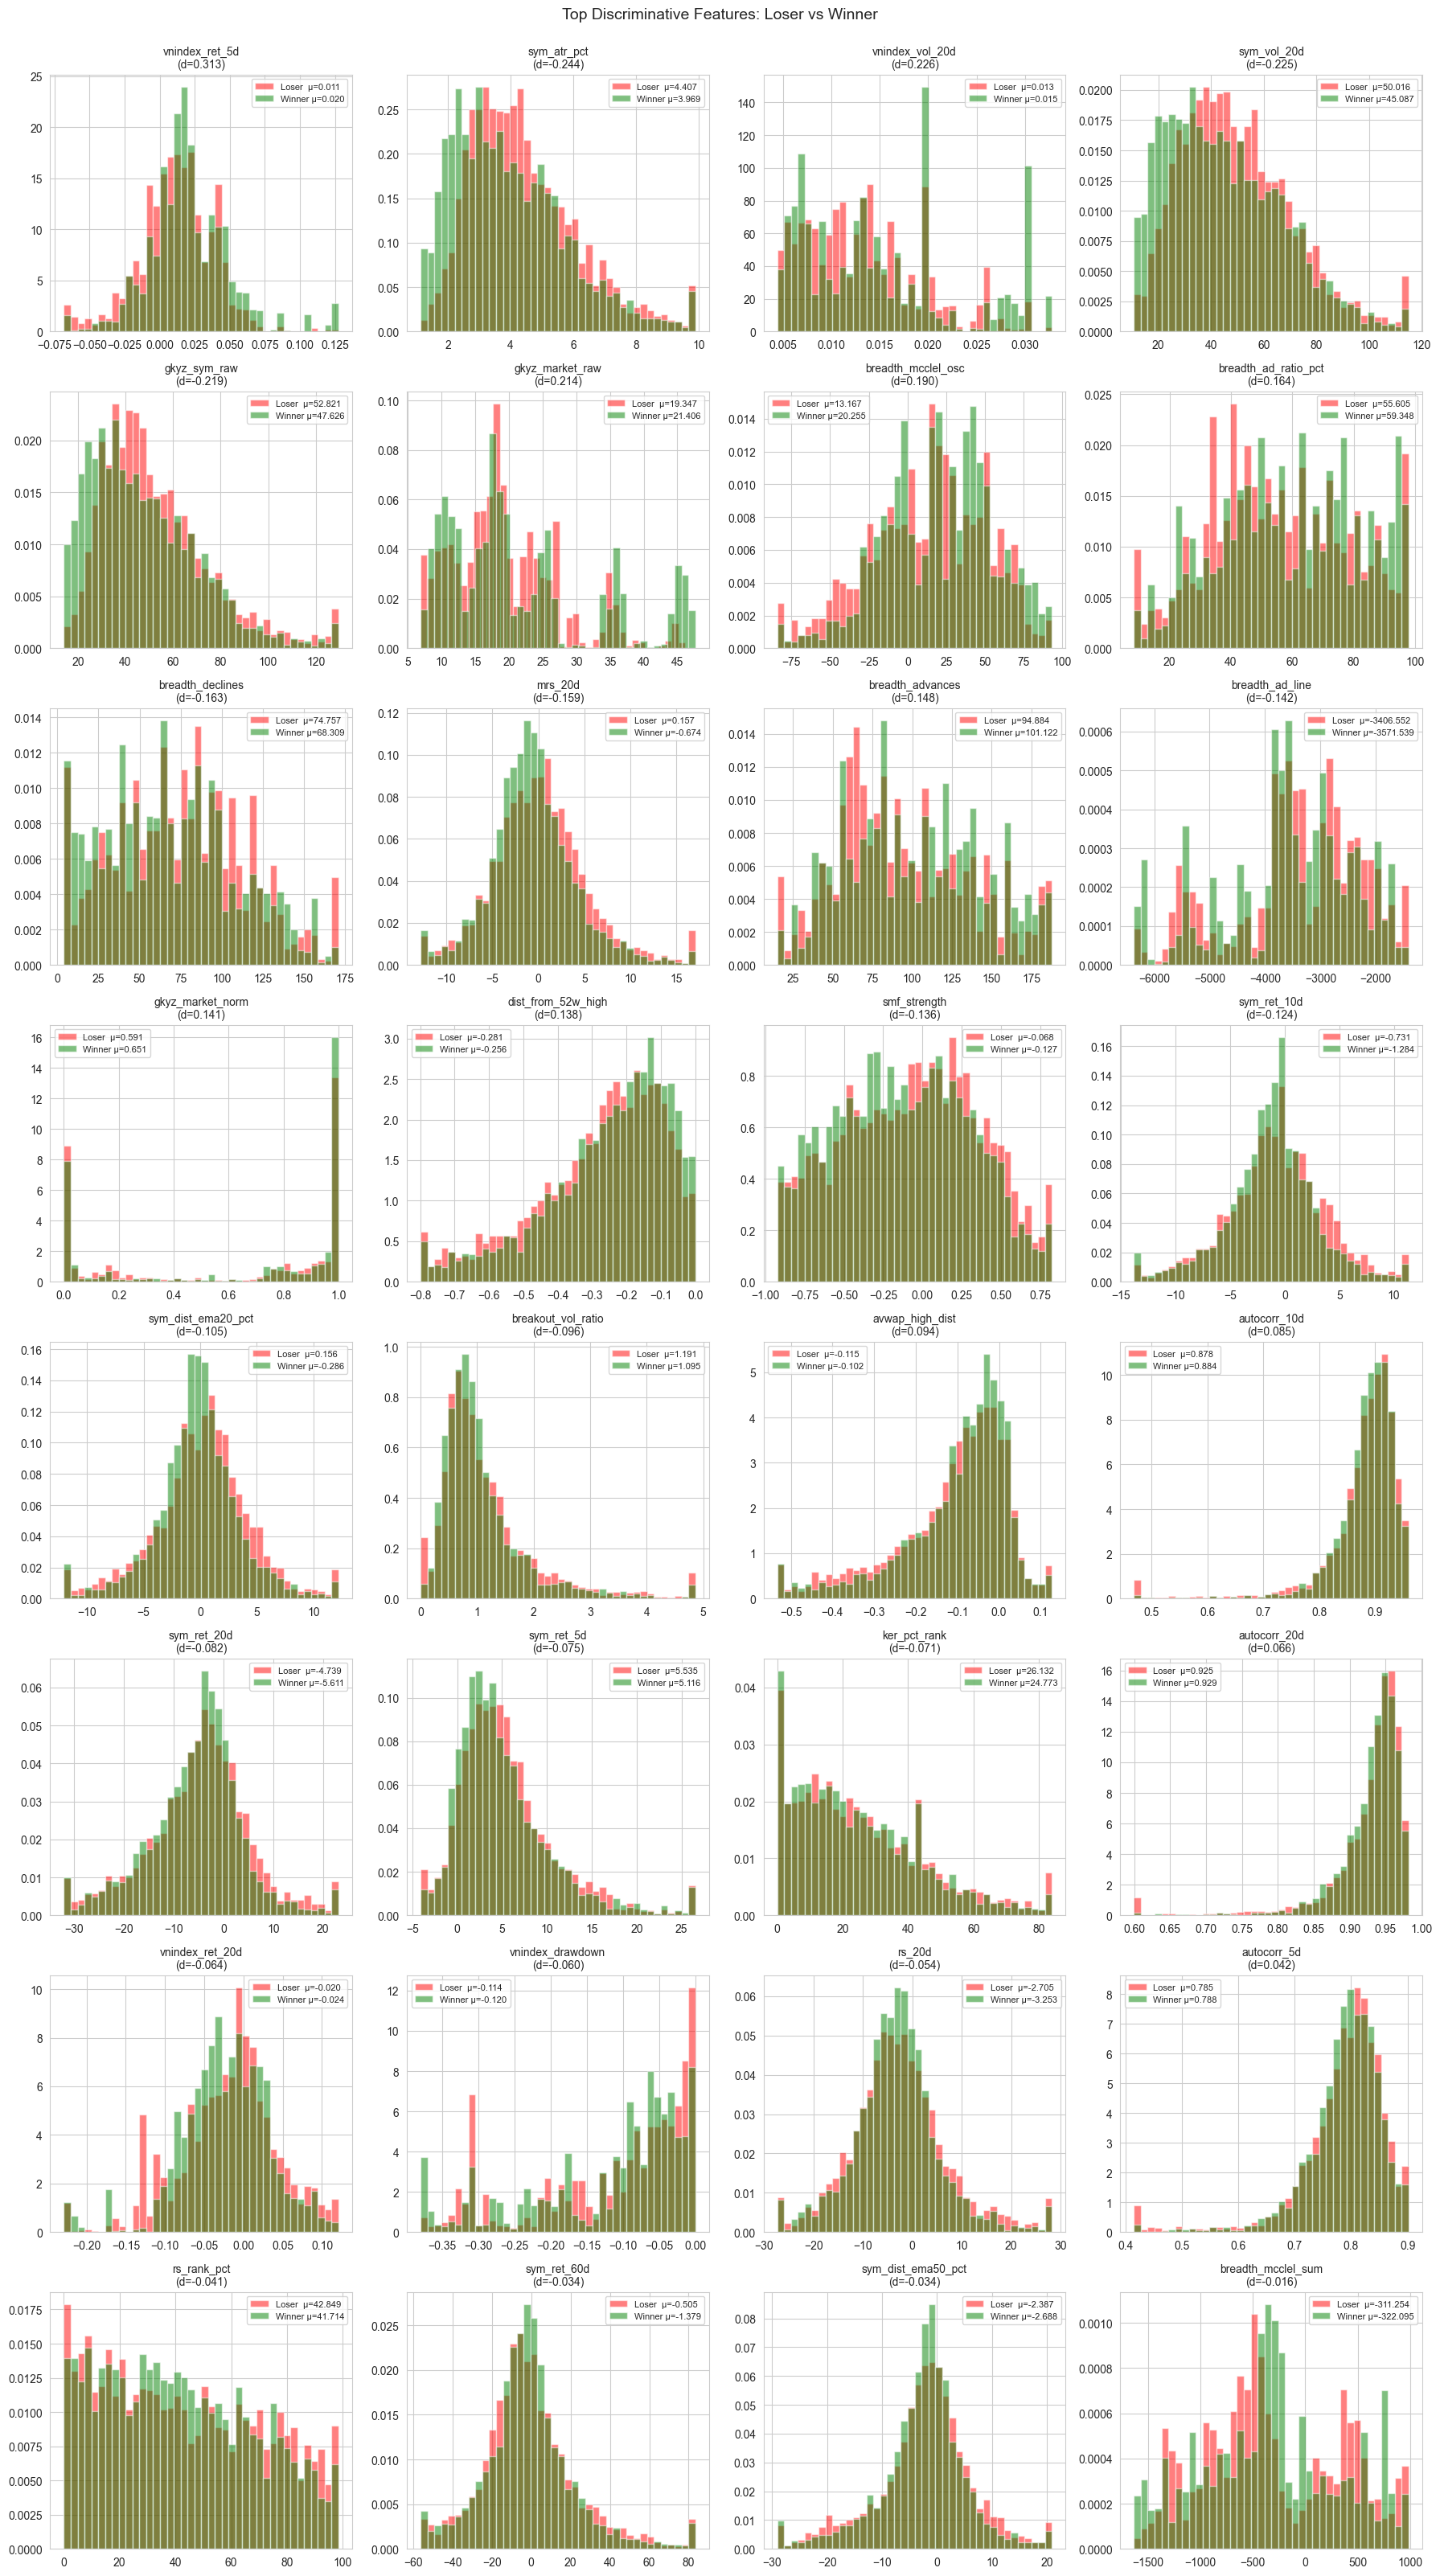

In [32]:
features_len = len(feature_cols)
fig, axes = plt.subplots(features_len // 4, 4, figsize=(18, features_len // 4 * 4))
for ax, feat in zip(axes.flat, discrim_df['feature'].tolist()):
    lv, wv = losers[feat].dropna(), winners[feat].dropna()
    p1  = min(lv.quantile(0.01), wv.quantile(0.01))
    p99 = max(lv.quantile(0.99), wv.quantile(0.99))
    ax.hist(lv.clip(p1,p99), bins=40, alpha=0.5,
            label=f'Loser  μ={lv.mean():.3f}', color='red',   density=True)
    ax.hist(wv.clip(p1,p99), bins=40, alpha=0.5,
            label=f'Winner μ={wv.mean():.3f}', color='green', density=True)
    d = discrim_df.set_index('feature').loc[feat,'cohen_d']
    ax.set_title(f'{feat}\n(d={d:.3f})', fontsize=10)
    ax.legend(fontsize=8)
plt.suptitle('Top Discriminative Features: Loser vs Winner', fontsize=14, y=1.00)
plt.tight_layout(); plt.show()

In [33]:
print("Cohen d:  <0.2=trivial  0.2-0.5=small  0.5-0.8=medium  >0.8=large")
strong = discrim_df[discrim_df['abs_cohen_d'] > 0.5]
medium = discrim_df[(discrim_df['abs_cohen_d']>0.2)&(discrim_df['abs_cohen_d']<=0.5)]
weak   = discrim_df[discrim_df['abs_cohen_d'] <= 0.2]
print(f"Strong={len(strong)}  Medium={len(medium)}  Weak={len(weak)}")
if len(strong):
    print(strong[['feature','loser_mean','winner_mean','cohen_d']].to_string(index=False))

Cohen d:  <0.2=trivial  0.2-0.5=small  0.5-0.8=medium  >0.8=large
Strong=0  Medium=6  Weak=29


## 5. Catastrophic Loss Deep Dive

In [34]:
catastrophic_vs_others = feature_discrimination(
    catastrophic,
    training_df[training_df['outcome']!='1_catastrophic_loss'],
    feature_cols,
)
print("Top 15 features distinguishing CATASTROPHIC losers:")
print(catastrophic_vs_others.head(15).to_string(index=False))

Top 15 features distinguishing CATASTROPHIC losers:
           feature  loser_mean  winner_mean   cohen_d  abs_cohen_d  ks_stat     ks_pvalue    mwu_pvalue
       sym_atr_pct    4.947110     3.498236 -0.825887     0.825887 0.385138 7.314862e-114 1.354084e-133
       sym_vol_20d   56.833953    39.678955 -0.792160     0.792160 0.346549  1.052402e-91 1.605539e-115
      gkyz_sym_raw   59.670021    42.385102 -0.725458     0.725458 0.357510  9.609753e-98 5.286636e-115
        sym_ret_5d    6.748876     3.865199 -0.507449     0.507449 0.279344  3.275264e-59  1.399882e-57
           mrs_20d    0.834634    -0.880794 -0.316309     0.316309 0.172410  1.342367e-22  3.323031e-18
   vnindex_ret_20d   -0.028581    -0.011792  0.272903     0.272903 0.150086  3.210963e-17  1.539186e-15
     gkyz_sym_norm    0.653297     0.544183 -0.270146     0.270146 0.138736  9.059783e-15  8.574480e-16
dist_from_52w_high   -0.291513    -0.243897  0.264053     0.264053 0.128489  1.003504e-12  1.150251e-11
  vnindex_dr

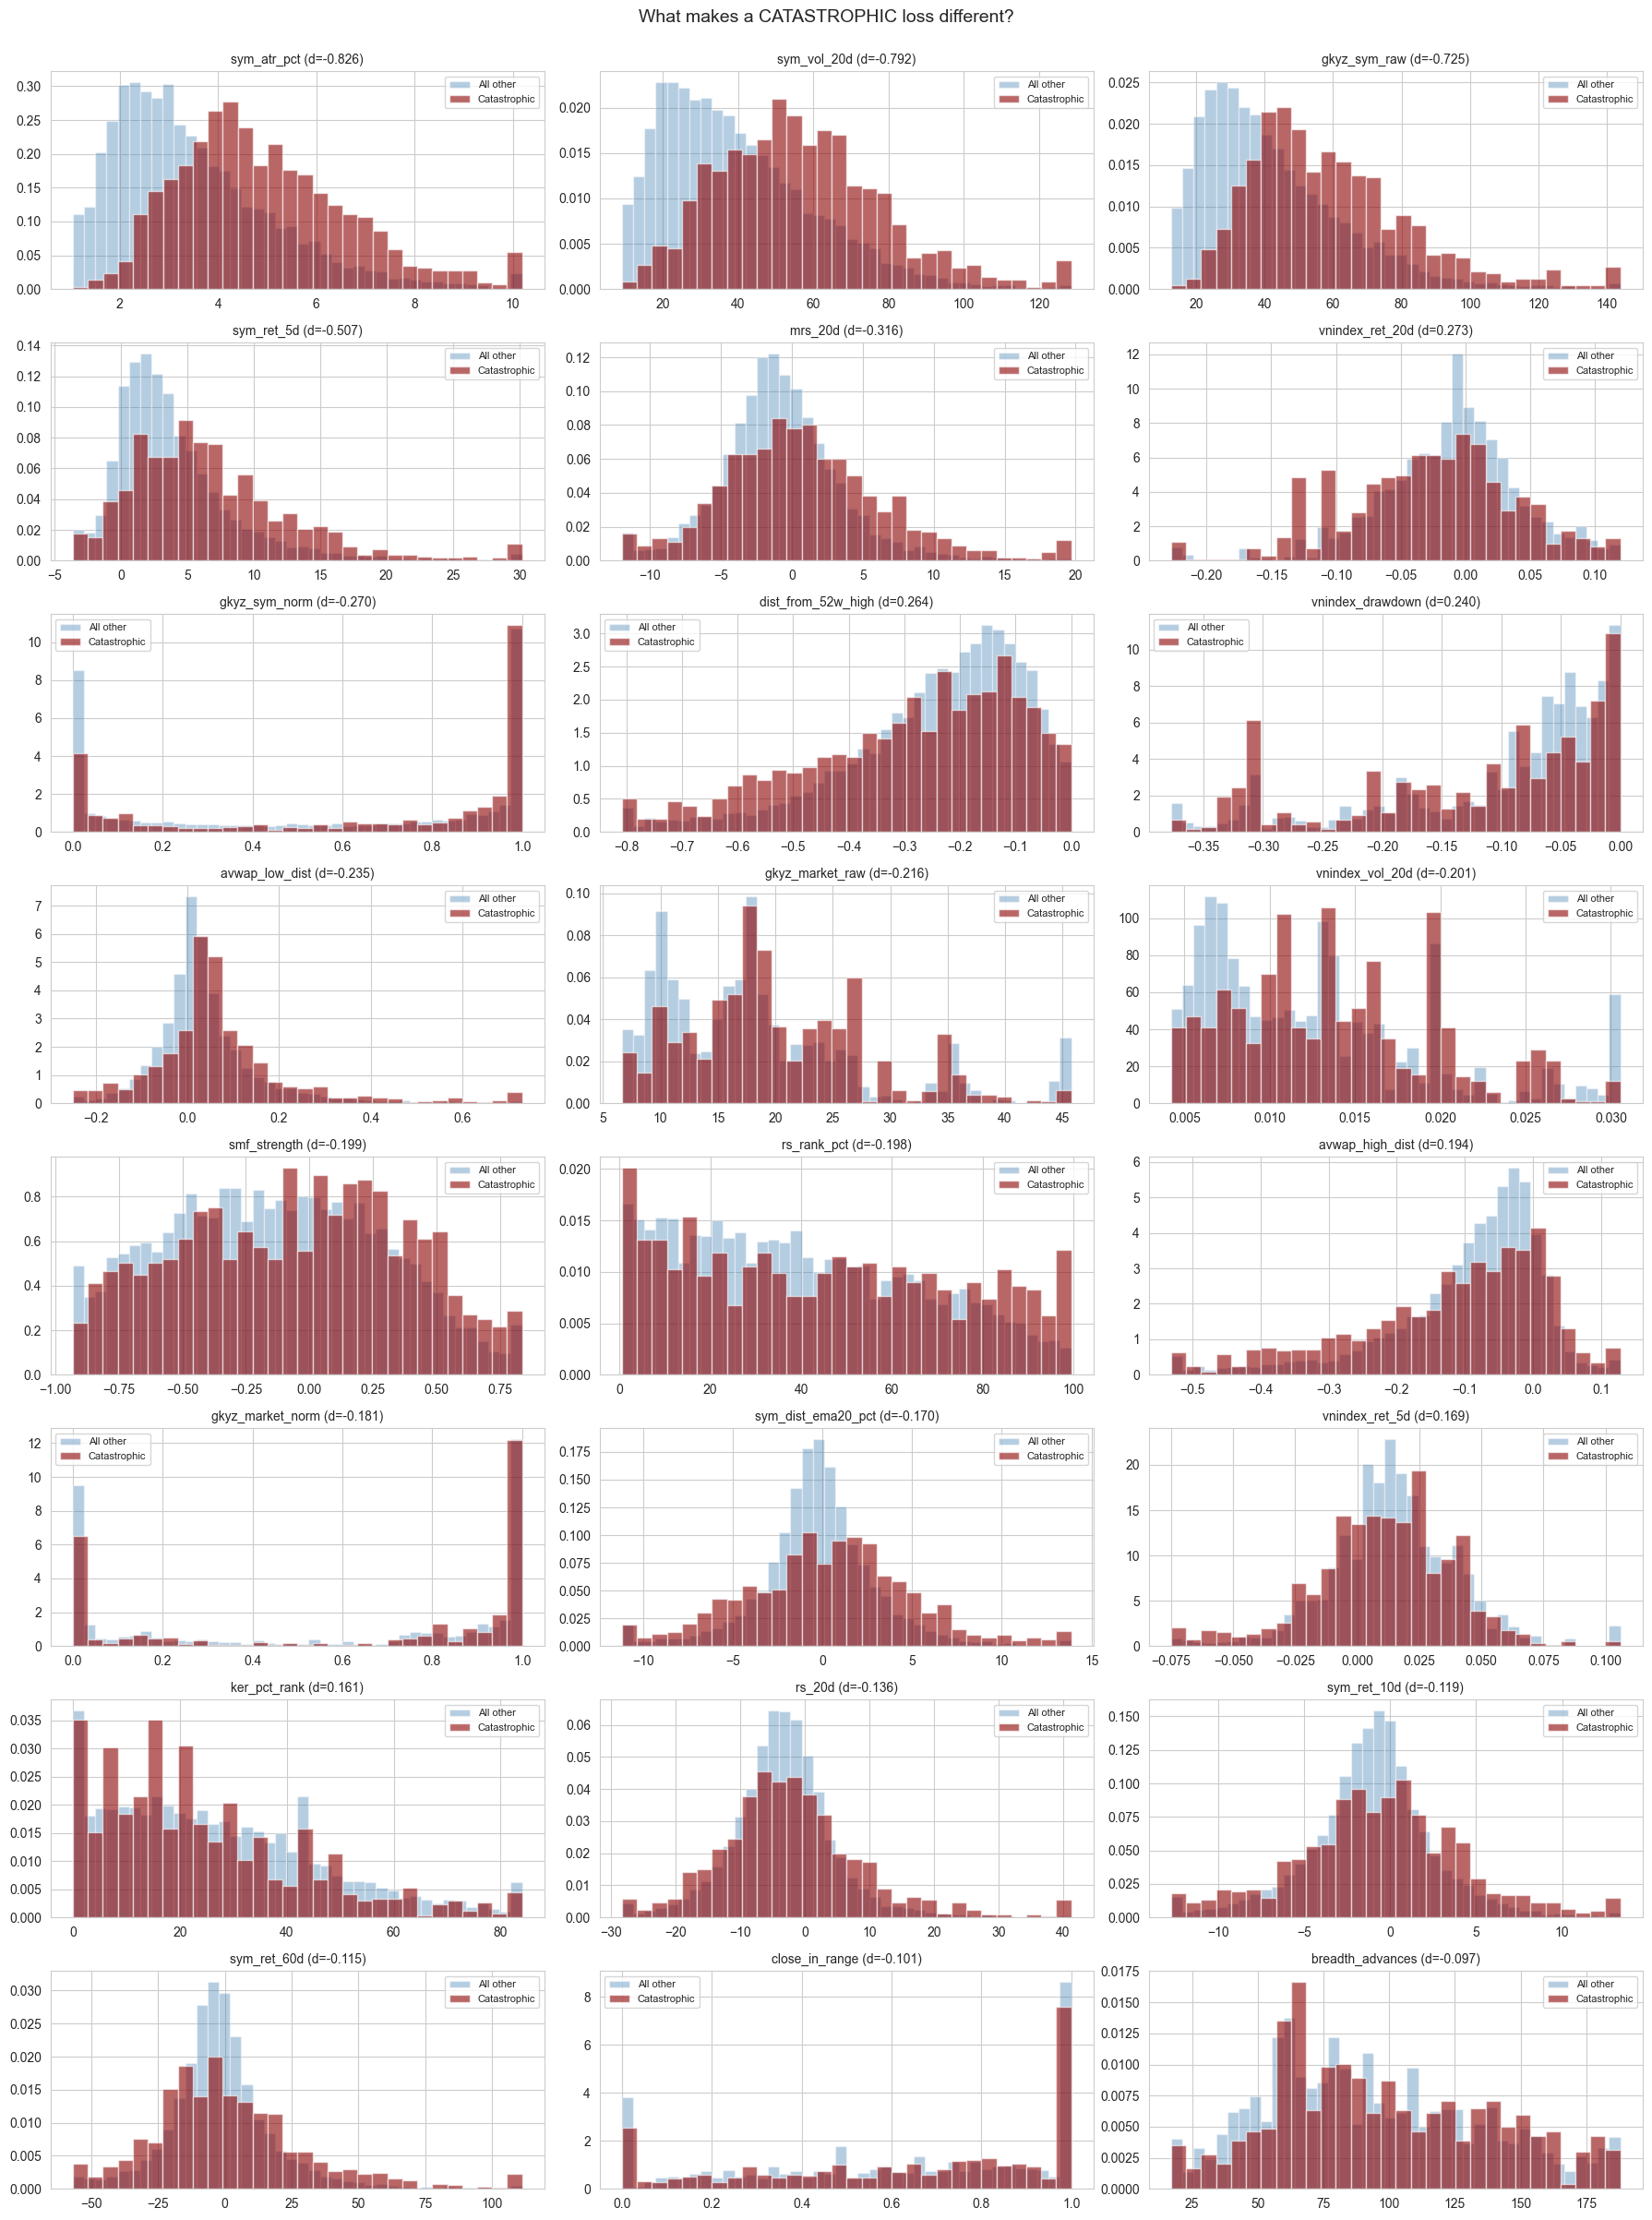

In [35]:
features_len = len(feature_cols)
# top_cat = catastrophic_vs_others.head(16)['feature'].tolist()
fig, axes = plt.subplots(features_len // 4, 3, figsize=(18, features_len // 4 * 3))
for ax, feat in zip(axes.flat, catastrophic_vs_others['feature'].tolist()):
    cv = catastrophic[feat].dropna()
    ov = training_df[training_df['outcome']!='1_catastrophic_loss'][feat].dropna()
    p1  = min(cv.quantile(0.01), ov.quantile(0.01))
    p99 = max(cv.quantile(0.99), ov.quantile(0.99))
    ax.hist(ov.clip(p1,p99), bins=40, alpha=0.4, label='All other', color='steelblue', density=True)
    ax.hist(cv.clip(p1,p99), bins=30, alpha=0.6, label='Catastrophic', color='darkred', density=True)
    d = catastrophic_vs_others.set_index('feature').loc[feat,'cohen_d']
    ax.set_title(f'{feat} (d={d:.3f})', fontsize=10)
    ax.legend(fontsize=8)
plt.suptitle('What makes a CATASTROPHIC loss different?', fontsize=14, y=1.00)
plt.tight_layout(); plt.show()

## 6. Time & Regime Analysis

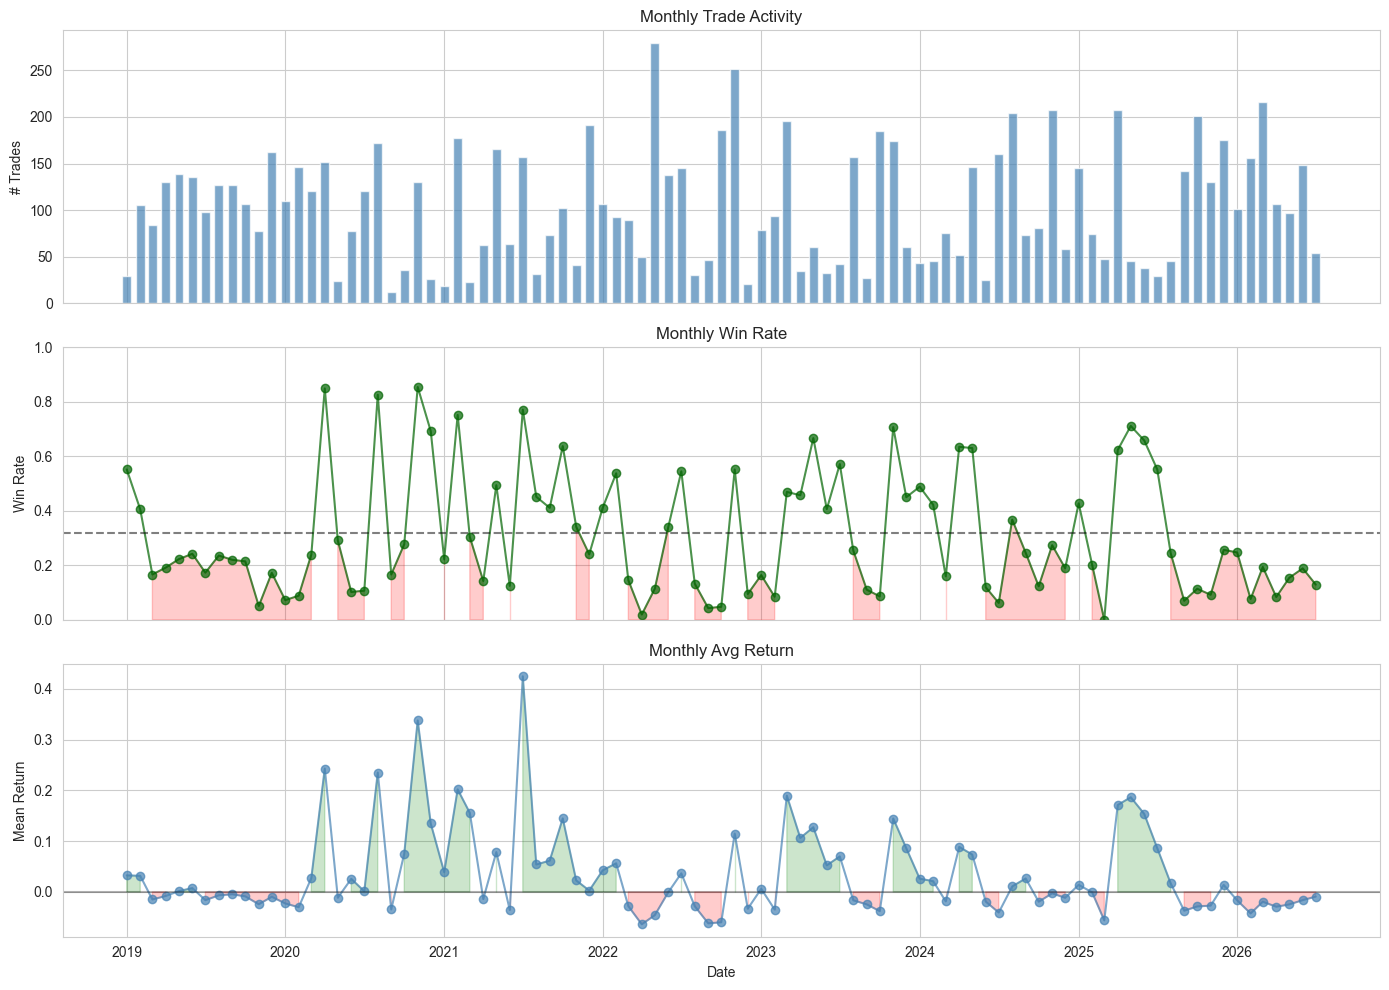

Top 10 worst months:
year_month  n_trades  win_rate  avg_return
2022-04-01        50  0.020000   -0.063727
2022-09-01        46  0.043478   -0.061798
2022-10-01       186  0.048387   -0.059753
2025-03-01        47  0.000000   -0.056012
2022-05-01       279  0.114695   -0.045725
2026-02-01       156  0.076923   -0.042382
2024-07-01       160  0.062500   -0.040558
2023-10-01       185  0.086486   -0.037815
2025-09-01       142  0.070423   -0.036925
2021-06-01        64  0.125000   -0.035438


In [36]:
training_df['year_month'] = training_df['entry_date'].dt.to_period('M')
monthly = training_df.groupby('year_month').agg(
    n_trades=('Y','count'), win_rate=('Y','mean'), avg_return=('net_return','mean'),
).reset_index()
monthly['year_month'] = monthly['year_month'].dt.to_timestamp()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].bar(monthly['year_month'], monthly['n_trades'], width=20, color='steelblue', alpha=0.7)
axes[0].set(ylabel='# Trades', title='Monthly Trade Activity')
axes[1].plot(monthly['year_month'], monthly['win_rate'], marker='o', color='darkgreen', alpha=0.7)
axes[1].axhline(training_df['Y'].mean(), color='black', linestyle='--', alpha=0.5)
axes[1].fill_between(monthly['year_month'], 0, monthly['win_rate'],
                     where=(monthly['win_rate']<0.4), color='red', alpha=0.2)
axes[1].set(ylabel='Win Rate', ylim=(0,1), title='Monthly Win Rate')
axes[2].plot(monthly['year_month'], monthly['avg_return'], marker='o', color='steelblue', alpha=0.7)
axes[2].axhline(0, color='black', alpha=0.3)
axes[2].fill_between(monthly['year_month'],0,monthly['avg_return'],
                     where=(monthly['avg_return']<0),color='red',alpha=0.2)
axes[2].fill_between(monthly['year_month'],0,monthly['avg_return'],
                     where=(monthly['avg_return']>0),color='green',alpha=0.2)
axes[2].set(ylabel='Mean Return', xlabel='Date', title='Monthly Avg Return')
plt.tight_layout(); plt.show()

worst_months = monthly.nsmallest(10,'avg_return')
print("Top 10 worst months:")
print(worst_months.to_string(index=False))

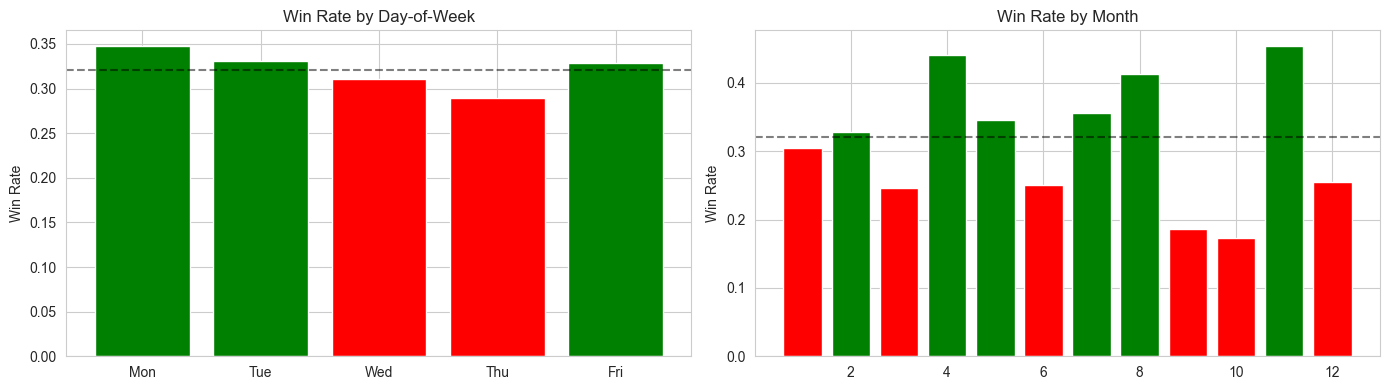

Day-of-week chi2 p=0.0016 — significant


In [37]:
from scipy.stats import chi2_contingency
training_df['dow']   = training_df['entry_date'].dt.dayofweek
training_df['month'] = training_df['entry_date'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
dow_s = training_df.groupby('dow').agg(win_rate=('Y','mean')).reset_index()
axes[0].bar(dow_s['dow'][:5], dow_s['win_rate'][:5],
            color=['red' if w<training_df['Y'].mean() else 'green' for w in dow_s['win_rate'][:5]])
axes[0].axhline(training_df['Y'].mean(), color='black', linestyle='--', alpha=0.5)
axes[0].set(xticks=range(5), xticklabels=['Mon','Tue','Wed','Thu','Fri'],
            ylabel='Win Rate', title='Win Rate by Day-of-Week')
mon_s = training_df.groupby('month').agg(win_rate=('Y','mean')).reset_index()
axes[1].bar(mon_s['month'], mon_s['win_rate'],
            color=['red' if w<training_df['Y'].mean() else 'green' for w in mon_s['win_rate']])
axes[1].axhline(training_df['Y'].mean(), color='black', linestyle='--', alpha=0.5)
axes[1].set(ylabel='Win Rate', title='Win Rate by Month')
plt.tight_layout(); plt.show()

ct = pd.crosstab(training_df['dow'], training_df['Y'])
_, p, _, _ = chi2_contingency(ct)
print(f"Day-of-week chi2 p={p:.4f} — {'significant' if p<0.05 else 'not significant'}")

## 7. Symbol-Level Hotspots

In [38]:
sym_stats = training_df.groupby('symbol').agg(
    n_trades=('Y','count'), win_rate=('Y','mean'),
    avg_return=('net_return','mean'), sum_return=('net_return','sum'),
).reset_index()
sym_stats = sym_stats[sym_stats['n_trades']>=10].sort_values('avg_return')
print("Worst 10:"); print(sym_stats.head(10).to_string(index=False))
print("\nBest 10:");  print(sym_stats.tail(10).to_string(index=False))

Worst 10:
symbol  n_trades  win_rate  avg_return  sum_return
   SBT        60  0.266667   -0.006256   -0.375386
   VNM        64  0.171875   -0.005090   -0.325751
   HHV        60  0.233333   -0.004460   -0.267601
   SAB        58  0.275862   -0.002746   -0.159275
   CTI        49  0.285714   -0.002138   -0.104769
   DDV        72  0.166667   -0.001540   -0.110895
   HNG        50  0.200000   -0.001229   -0.061466
   VRE        54  0.314815    0.000964    0.052047
   APH        44  0.318182    0.001433    0.063062
   OCB        41  0.317073    0.001628    0.066760

Best 10:
symbol  n_trades  win_rate  avg_return  sum_return
   TIG        43  0.348837    0.089087    3.830744
   PDR        45  0.288889    0.091718    4.127330
   AGR        46  0.369565    0.093689    4.309694
   VGI        46  0.391304    0.094458    4.345081
   IDJ        58  0.293103    0.096012    5.568719
   HAH        42  0.428571    0.100942    4.239546
   FRT        42  0.404762    0.105187    4.417851
   HUT     

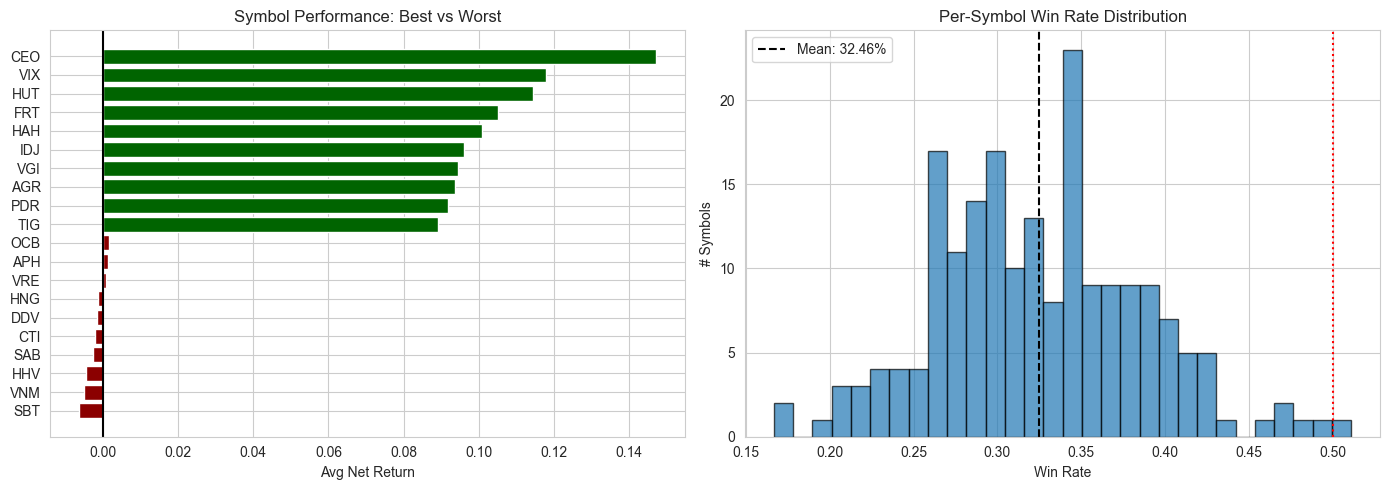

Chronic losers (winrate<35%, >=20 trades): 134
 symbol  n_trades  win_rate  avg_return
    SBT        60  0.266667   -0.006256
    VNM        64  0.171875   -0.005090
    HHV        60  0.233333   -0.004460
    SAB        58  0.275862   -0.002746
    CTI        49  0.285714   -0.002138
    DDV        72  0.166667   -0.001540
    HNG        50  0.200000   -0.001229
    VRE        54  0.314815    0.000964
    APH        44  0.318182    0.001433
    OCB        41  0.317073    0.001628
    SCS        54  0.296296    0.001853
    REE        57  0.263158    0.001890
    PAC        57  0.210526    0.003804
    VEA        47  0.340426    0.004747
    AGG        42  0.238095    0.004804
    NT2        52  0.269231    0.004851
    PNJ        58  0.275862    0.006256
    HPX        54  0.240741    0.006871
    MSB        41  0.341463    0.009484
    DXS        34  0.294118    0.009824
    MSN        54  0.333333    0.010253
    VHC        55  0.272727    0.011012
    ACV        53  0.264151    0.

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
combined = pd.concat([sym_stats.head(10), sym_stats.tail(10)])
axes[0].barh(combined['symbol'], combined['avg_return'],
             color=['darkred']*10+['darkgreen']*10)
axes[0].axvline(0, color='black')
axes[0].set(xlabel='Avg Net Return', title='Symbol Performance: Best vs Worst')
axes[1].hist(sym_stats['win_rate'], bins=30, alpha=0.7, edgecolor='black')
axes[1].axvline(sym_stats['win_rate'].mean(), color='black', linestyle='--',
                label=f"Mean: {sym_stats['win_rate'].mean():.2%}")
axes[1].axvline(0.5, color='red', linestyle=':')
axes[1].set(xlabel='Win Rate', ylabel='# Symbols', title='Per-Symbol Win Rate Distribution')
axes[1].legend()
plt.tight_layout(); plt.show()

chronic_losers = sym_stats[(sym_stats['win_rate']<0.35)&(sym_stats['n_trades']>=20)]
print(f"Chronic losers (winrate<35%, >=20 trades): {len(chronic_losers)}")
if len(chronic_losers):
    print(chronic_losers[['symbol','n_trades','win_rate','avg_return']].to_string(index=False))

## 8. Holding Period Analysis

`holding_days` is computed here for visualisation only — it is NOT a `@feature` because `exit_date` is look-ahead at entry time.

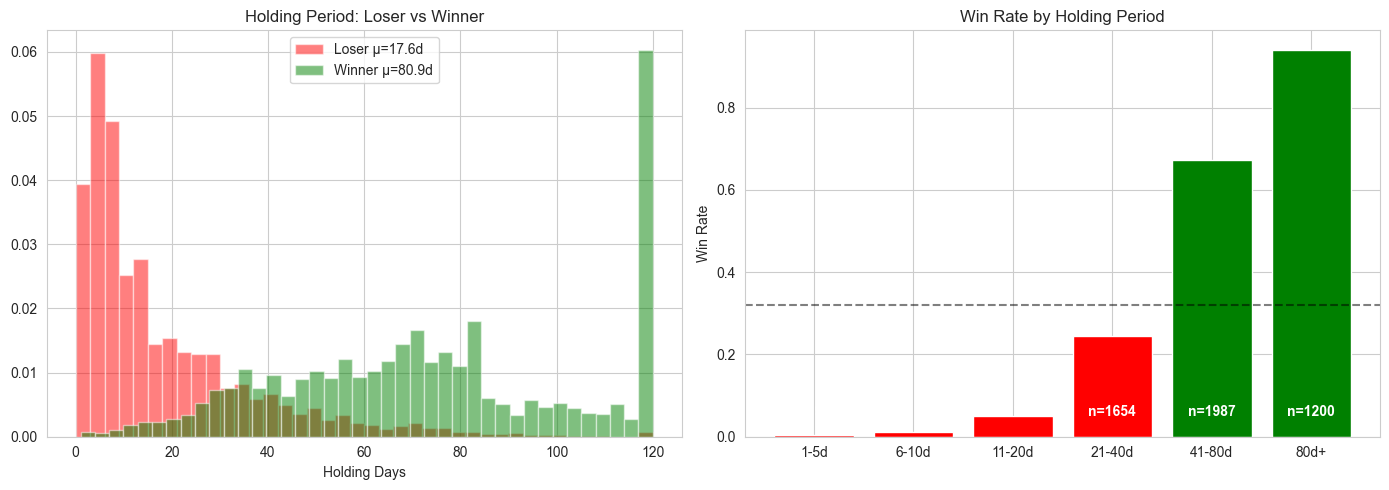

Loser median hold: 11d
Winner median hold: 72d


In [40]:
holding_days = (training_df['exit_date'] - training_df['entry_date']).dt.days

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for grp, col, lbl in [
    (training_df[training_df['Y']==0], 'red',   'Loser'),
    (training_df[training_df['Y']==1], 'green', 'Winner'),
]:
    v = holding_days.loc[grp.index].dropna()
    ax.hist(v.clip(0, 120), bins=40, alpha=0.5,
            label=f'{lbl} μ={v.mean():.1f}d', color=col, density=True)
ax.set(xlabel='Holding Days', title='Holding Period: Loser vs Winner')
ax.legend()

ax = axes[1]
hold_bins   = [0, 5, 10, 20, 40, 80, 200]
hold_labels = ['1-5d','6-10d','11-20d','21-40d','41-80d','80d+']
hld_col = pd.cut(holding_days, bins=hold_bins, labels=hold_labels)
hld = training_df.assign(_hld=hld_col).groupby('_hld', observed=True).agg(
    win_rate=('Y','mean'), n=('Y','count')
)
ax.bar(range(len(hld)), hld['win_rate'],
       color=['red' if w < training_df['Y'].mean() else 'green' for w in hld['win_rate']])
ax.axhline(training_df['Y'].mean(), color='black', linestyle='--', alpha=0.5)
ax.set(xticks=range(len(hld)), xticklabels=hld.index, ylabel='Win Rate',
       title='Win Rate by Holding Period')
for i, n in enumerate(hld['n']):
    ax.text(i, 0.05, f'n={n}', ha='center', color='white', fontweight='bold')

plt.tight_layout(); plt.show()
print(f"Loser median hold: {holding_days.loc[training_df[training_df['Y']==0].index].median():.0f}d")
print(f"Winner median hold: {holding_days.loc[training_df[training_df['Y']==1].index].median():.0f}d")

## 9. Visualize the Worst 9 Losers

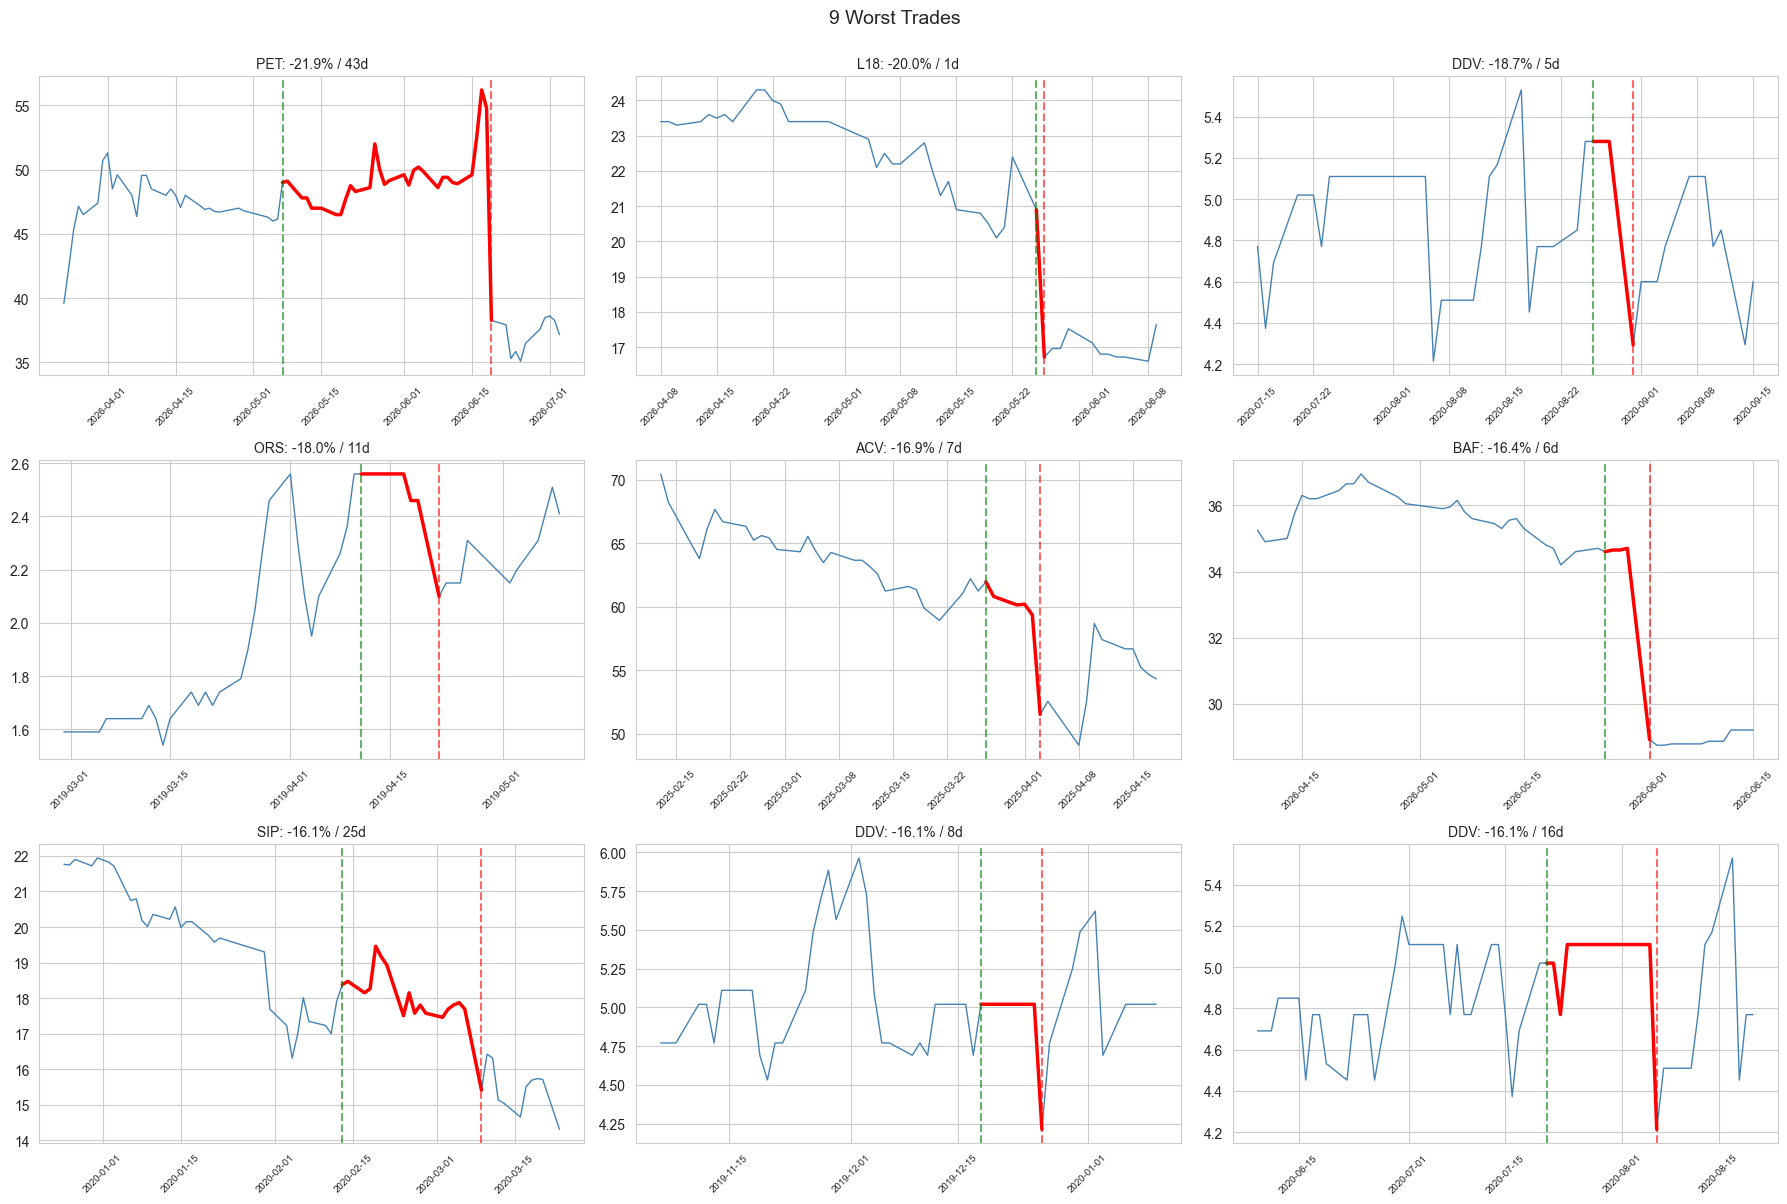

In [41]:
if stocks is None:
    print("WARNING: stocks panel not available")
else:
    worst9 = training_df.nsmallest(9,'net_return').reset_index(drop=True)
    # worst9 = training_df.nsmallest(18, 'net_return').iloc[9:18].reset_index(drop=True)
    fig, axes = plt.subplots(3, 3, figsize=(18, 12))
    for ax, (_,trade) in zip(axes.flat, worst9.iterrows()):
        sym,t0,t1 = trade['symbol'], trade['entry_date'], trade['exit_date']
        if sym not in stocks['close'].columns:
            ax.text(0.5,0.5,f'{sym}\nno data',ha='center',va='center'); continue
        idx = stocks.index
        cs  = idx[max(0, idx.get_loc(t0)-30)]
        ce  = idx[min(len(idx)-1, idx.get_loc(t1)+10)]
        full = stocks['close'][sym].loc[cs:ce]
        ax.plot(full.index, full.values, color='steelblue', lw=1)
        tp = stocks['close'][sym].loc[t0:t1]
        ax.plot(tp.index, tp.values, color='red', lw=2.5)
        ax.axvline(t0, color='green', linestyle='--', alpha=0.6)
        ax.axvline(t1, color='red',   linestyle='--', alpha=0.6)
        ax.set_title(f"{sym}: {trade['net_return']:.1%} / {(t1-t0).days}d", fontsize=10)
        ax.tick_params(axis='x', rotation=45, labelsize=7)
    plt.suptitle('9 Worst Trades', fontsize=14, y=1.00)
    plt.tight_layout(); plt.show()

## 9b. Worst Losers by GKYZ Market Regime

GKYZ threshold = 0.4  |  losers = 6277
  Calm market  (GKYZ ≤ 0.4) worst 9       n=   9  mean=-17.42%  median=-16.42%  GKYZ_avg=0.070
  High-vol mkt (GKYZ > 0.8) worst 9       n=   9  mean=-15.32%  median=-15.09%  GKYZ_avg=0.964


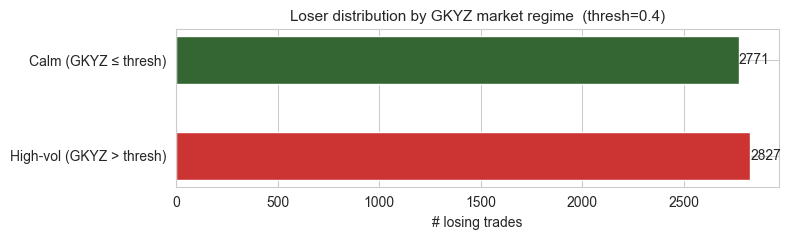

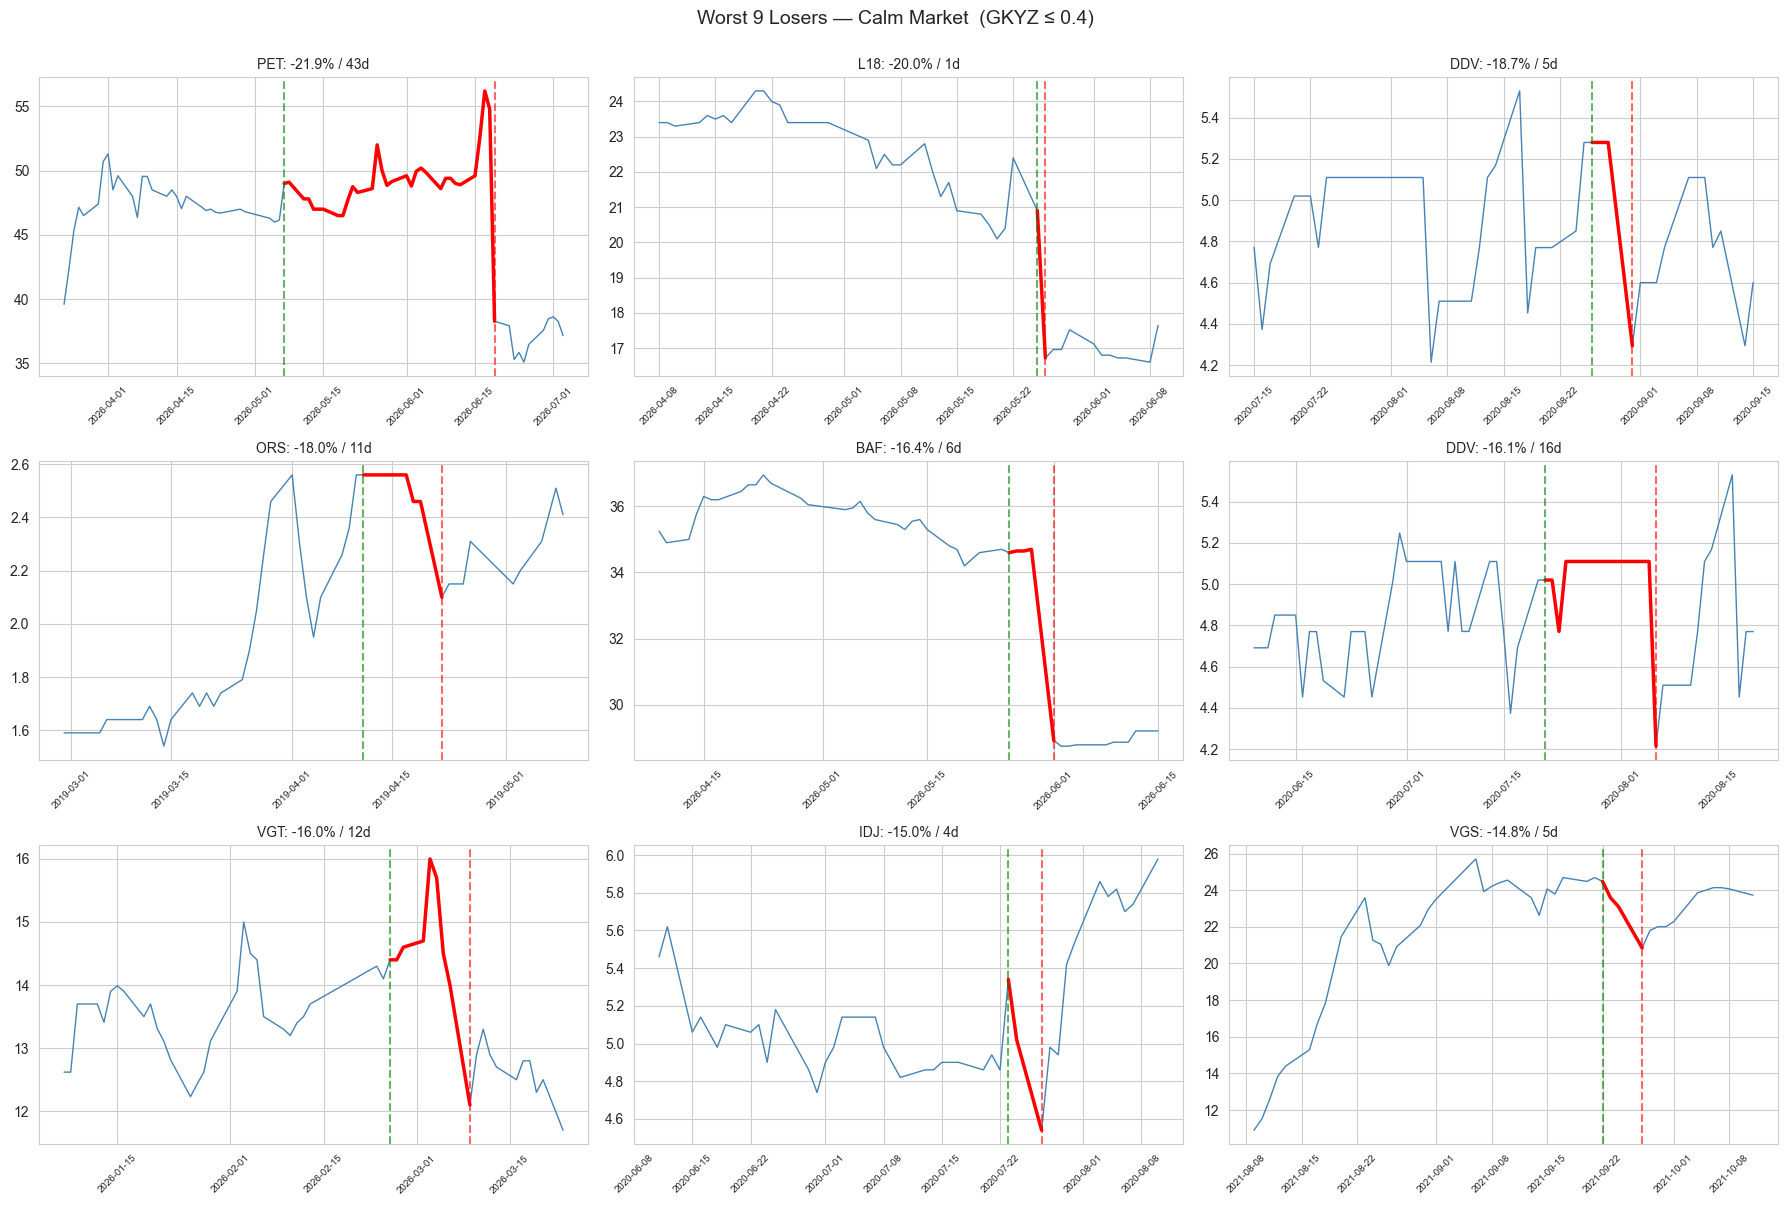

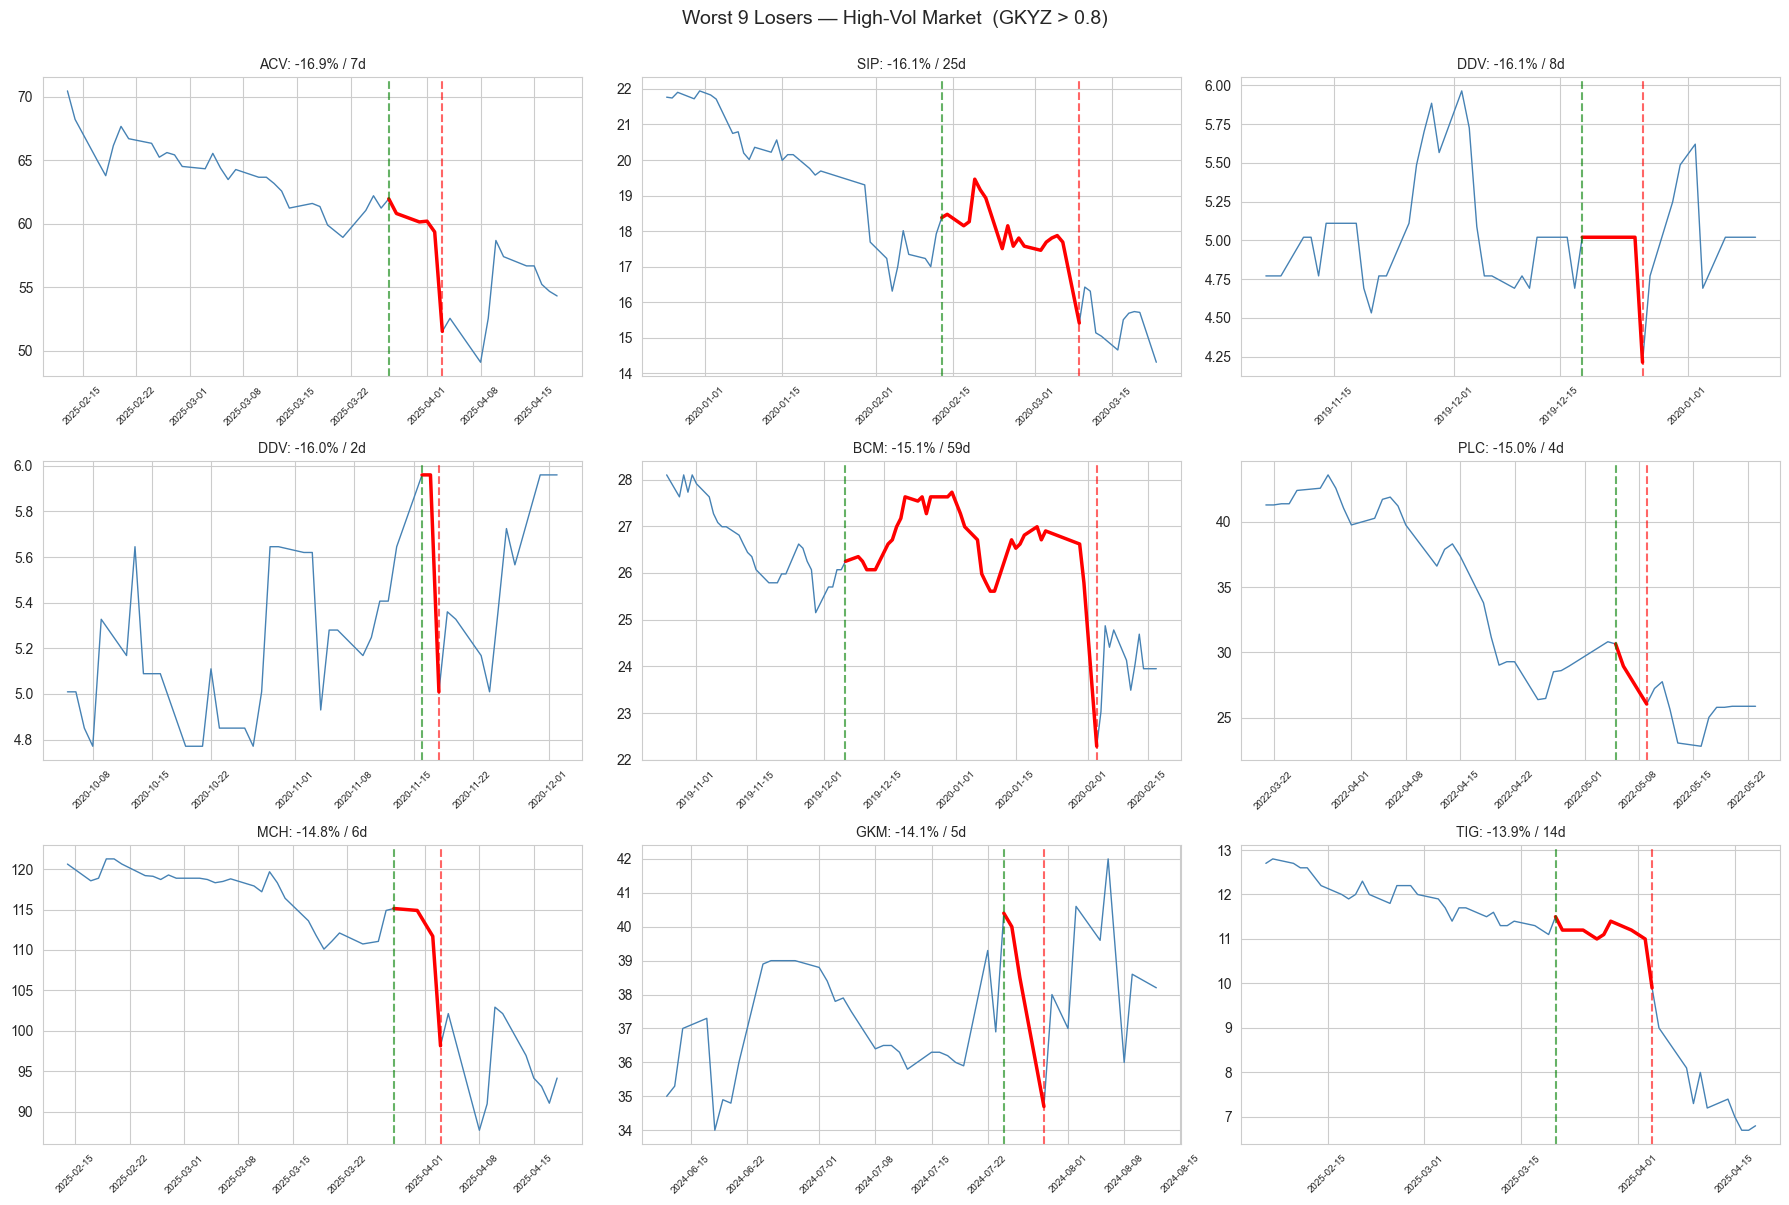

In [42]:
GKYZ_COL    = 'gkyz_market_norm'
N_WORST     = 9
LOW_VOL_GKYZ_THRESH = 0.4   # split: ≤ = Calm market, > = High-vol market
HIGH_VOL_GKYZ_THRESH = 0.8

if stocks is None:
    print("WARNING: stocks panel not available — run §2 data loader first")
elif GKYZ_COL not in training_df.columns:
    print(f"'{GKYZ_COL}' not found — run §3 feature engineering + _apply_all() first")
else:
    losers = training_df[training_df['net_return'] < 0].copy()

    calm_worst   = (losers[losers[GKYZ_COL] <= LOW_VOL_GKYZ_THRESH]
                    .nsmallest(N_WORST, 'net_return').reset_index(drop=True))
    hivol_worst  = (losers[losers[GKYZ_COL] >  HIGH_VOL_GKYZ_THRESH]
                    .nsmallest(N_WORST, 'net_return').reset_index(drop=True))

    # ── Summary ───────────────────────────────────────────────────────────────
    def _regime_stats(grp, label):
        if grp.empty:
            print(f"  {label}: 0 trades"); return
        print(f"  {label:38s}  n={len(grp):4d}  "
              f"mean={grp['net_return'].mean():.2%}  "
              f"median={grp['net_return'].median():.2%}  "
              f"GKYZ_avg={grp[GKYZ_COL].mean():.3f}")

    print(f"GKYZ threshold = {LOW_VOL_GKYZ_THRESH}  |  losers = {len(losers)}")
    _regime_stats(calm_worst,  f"Calm market  (GKYZ ≤ {LOW_VOL_GKYZ_THRESH}) worst {N_WORST}")
    _regime_stats(hivol_worst, f"High-vol mkt (GKYZ > {HIGH_VOL_GKYZ_THRESH}) worst {N_WORST}")

    # ── Chart helper (same style as §9 worst-9 grid) ────────────────────────────
    def _plot_worst(subset, title):
        if subset.empty:
            print(f"No trades for: {title}"); return

        fig, axes = plt.subplots(3, 3, figsize=(18, 12))
        for ax, (_, trade) in zip(axes.flat, subset.iterrows()):
            sym, t0, t1 = trade['symbol'], trade['entry_date'], trade['exit_date']
            if sym not in stocks['close'].columns:
                ax.text(0.5, 0.5, f'{sym}\nno data', ha='center', va='center'); continue
            idx = stocks.index
            cs = idx[max(0, idx.get_loc(t0) - 30)]
            ce = idx[min(len(idx) - 1, idx.get_loc(t1) + 10)]
            full = stocks['close'][sym].loc[cs:ce]
            ax.plot(full.index, full.values, color='steelblue', lw=1)
            tp = stocks['close'][sym].loc[t0:t1]
            ax.plot(tp.index, tp.values, color='red', lw=2.5)
            ax.axvline(t0, color='green', linestyle='--', alpha=0.6)
            ax.axvline(t1, color='red', linestyle='--', alpha=0.6)
            ax.set_title(f"{sym}: {trade['net_return']:.1%} / {(t1 - t0).days}d", fontsize=10)
            ax.tick_params(axis='x', rotation=45, labelsize=7)
        plt.suptitle(title, fontsize=14, y=1.00)
        plt.tight_layout(); plt.show()

    # ── Regime distribution bar ───────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 2.5))
    has_gkyz = losers[GKYZ_COL].notna()
    calm_n   = (losers.loc[has_gkyz, GKYZ_COL] <= LOW_VOL_GKYZ_THRESH).sum()
    hivol_n  = (losers.loc[has_gkyz, GKYZ_COL] >  HIGH_VOL_GKYZ_THRESH).sum()
    ax.barh(['High-vol (GKYZ > thresh)', 'Calm (GKYZ ≤ thresh)'],
            [hivol_n, calm_n],
            color=['#cc3333', '#336633'], height=0.5)
    ax.set_xlabel('# losing trades')
    ax.set_title(f'Loser distribution by GKYZ market regime  (thresh={LOW_VOL_GKYZ_THRESH})', fontsize=11)
    for i, v in enumerate([hivol_n, calm_n]):
        ax.text(v + 0.3, i, str(v), va='center', fontsize=10)
    plt.tight_layout(); plt.show()

    # ── Grids ─────────────────────────────────────────────────────────────────
    _plot_worst(calm_worst,
                f"Worst {N_WORST} Losers — Calm Market  (GKYZ ≤ {LOW_VOL_GKYZ_THRESH})")
    _plot_worst(hivol_worst,
                f"Worst {N_WORST} Losers — High-Vol Market  (GKYZ > {HIGH_VOL_GKYZ_THRESH})")


## 9c. GKYZ Volatility Around Entry (entry−5 → entry+5 bars)

**Forensic (post-entry) — NOT a `@feature`** (uses future bars, look-ahead at entry).

Hypothesis: losers experience a volatility *expansion* right after entry — the
breakout resolves into a whipsaw — and/or enter after an abnormal vol *run-up*.
Track each symbol's annualized GKYZ vol from `H` bars **before** to `H` bars
**after** entry and compare loser vs winner cohorts.

Columns computed (analysis-only, dropped before export):
- `gkyz_at_pre5`    : symbol GKYZ (annualized %) `H` bars **before** entry
- `gkyz_at_entry`   : GKYZ on the entry bar
- `gkyz_at_5`       : GKYZ `H` bars **after** entry
- `gkyz_pre5_delta` : `gkyz_at_entry − gkyz_at_pre5`   (vol run-up into entry)
- `gkyz_5_delta`    : `gkyz_at_5 − gkyz_at_entry`       (post-entry vol change)
- `gkyz_5_ratio`    : `gkyz_at_5 / gkyz_at_entry`        (relative post-entry change)
- `gkyz_5_max`      : max GKYZ over bars entry..entry+H  (worst intra-path vol)


GKYZ path entry-5 → entry+5 bars   (n_loser=6430, n_winner=3031)

metric             loser_mean  winner_mean   cohen_d
gkyz_at_pre5           43.116       45.827    -0.119
gkyz_at_entry          42.786       46.936    -0.182
gkyz_at_5              42.381       46.797    -0.201
gkyz_pre5_delta        -0.330        1.109    -0.234
gkyz_5_delta           -0.405       -0.139    -0.040
gkyz_5_ratio            1.003        1.012    -0.055
gkyz_5_max             44.878       48.995    -0.176


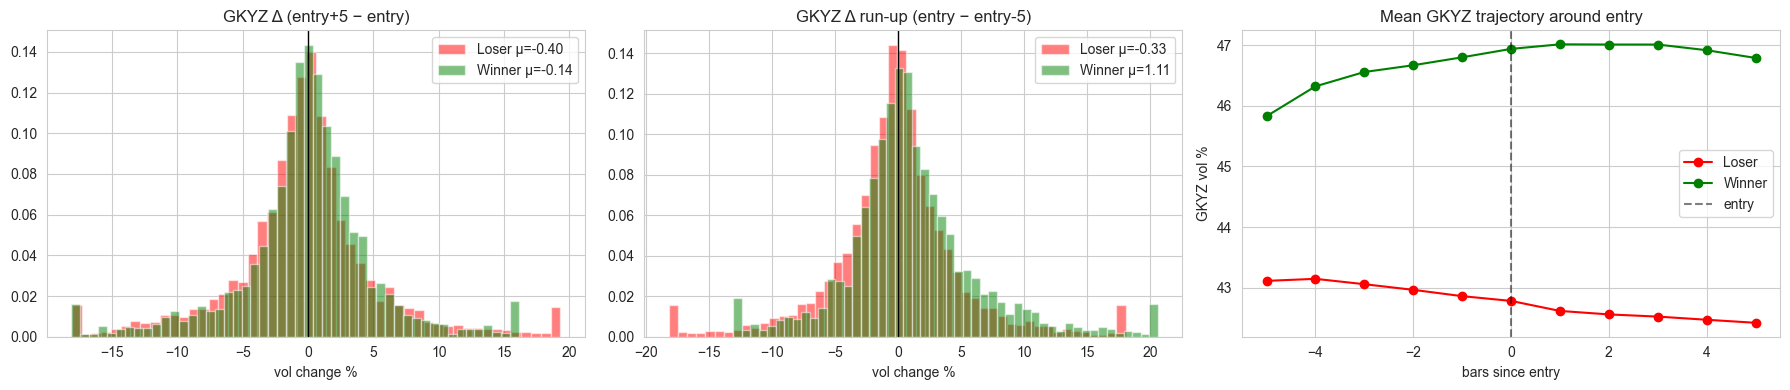

In [43]:
# ── GKYZ volatility path: entry−H → entry+H bars (pre/post-entry forensic) ────
H_BARS = 5   # bars before / after entry to measure

if stocks is None:
    print("WARNING: stocks panel not available — run §1 data loader first")
else:
    from backend.app.services.indicators.gkyz_volatility import gkyz_volatility_nb

    idx  = pd.DatetimeIndex(stocks['close'].index).normalize()
    syms = [s for s in training_df['symbol'].unique() if s in stocks['close'].columns]

    # Annualized GKYZ (raw %) for every symbol at once
    o2d = np.ascontiguousarray(stocks['open'][syms].values,  dtype=np.float64)
    h2d = np.ascontiguousarray(stocks['high'][syms].values,  dtype=np.float64)
    l2d = np.ascontiguousarray(stocks['low'][syms].values,   dtype=np.float64)
    c2d = np.ascontiguousarray(stocks['close'][syms].values, dtype=np.float64)
    gkyz_raw = gkyz_volatility_nb(c2d, o2d, h2d, l2d, window=21, normalize=False)  # (T, n_syms)
    col_of   = {s: j for j, s in enumerate(syms)}
    n_bars   = len(idx)

    rows = []
    for _, r in training_df.iterrows():
        sym = r['symbol']
        pre = e = f5 = pdlt = dlt = rat = pmax = np.nan
        if sym in col_of:
            j  = col_of[sym]
            t0 = pd.Timestamp(r['entry_date']).normalize()
            p0 = idx.get_indexer([t0], method='ffill')[0]   # entry bar position
            if p0 >= 0:
                pm = max(p0 - H_BARS, 0)
                p5 = min(p0 + H_BARS, n_bars - 1)
                pre = gkyz_raw[pm, j]
                e   = gkyz_raw[p0, j]
                f5  = gkyz_raw[p5, j]
                if np.isfinite(e) and np.isfinite(pre):
                    pdlt = e - pre
                if np.isfinite(e) and np.isfinite(f5):
                    dlt  = f5 - e
                    rat  = f5 / e if e > 0 else np.nan
                    pmax = np.nanmax(gkyz_raw[p0:p5 + 1, j])
        rows.append((pre, e, f5, pdlt, dlt, rat, pmax))

    post = pd.DataFrame(rows, index=training_df.index,
                        columns=['gkyz_at_pre5','gkyz_at_entry','gkyz_at_5',
                                 'gkyz_pre5_delta','gkyz_5_delta','gkyz_5_ratio','gkyz_5_max'])
    for c in post.columns:
        training_df[c] = post[c].values

    _POST_COLS = list(post.columns)

    # ── Loser vs Winner comparison ────────────────────────────────────────────
    L = training_df[training_df['Y'] == 0]
    W = training_df[training_df['Y'] == 1]
    print(f"GKYZ path entry-{H_BARS} → entry+{H_BARS} bars   (n_loser={len(L)}, n_winner={len(W)})\n")
    print(f"{'metric':16s}{'loser_mean':>13s}{'winner_mean':>13s}{'cohen_d':>10s}")
    for c in _POST_COLS:
        a, b = L[c].dropna().values, W[c].dropna().values
        pooled = np.sqrt((np.var(a, ddof=1) + np.var(b, ddof=1)) / 2) + 1e-9
        d = (np.mean(a) - np.mean(b)) / pooled      # loser − winner
        print(f"{c:16s}{np.mean(a):>13.3f}{np.mean(b):>13.3f}{d:>10.3f}")

    # ── Plots ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(1, 3, figsize=(18, 4))
    for a_, col, lbl in [(L, 'red', 'Loser'), (W, 'green', 'Winner')]:
        v = a_['gkyz_5_delta'].dropna()
        ax[0].hist(v.clip(v.quantile(0.01), v.quantile(0.99)), bins=50, alpha=0.5,
                   density=True, color=col, label=f'{lbl} μ={v.mean():.2f}')
    ax[0].axvline(0, color='black', lw=1)
    ax[0].set(title=f'GKYZ Δ (entry+{H_BARS} − entry)', xlabel='vol change %'); ax[0].legend()

    for a_, col, lbl in [(L, 'red', 'Loser'), (W, 'green', 'Winner')]:
        v = a_['gkyz_pre5_delta'].dropna()
        ax[1].hist(v.clip(v.quantile(0.01), v.quantile(0.99)), bins=50, alpha=0.5,
                   density=True, color=col, label=f'{lbl} μ={v.mean():.2f}')
    ax[1].axvline(0, color='black', lw=1)
    ax[1].set(title=f'GKYZ Δ run-up (entry − entry-{H_BARS})', xlabel='vol change %'); ax[1].legend()

    # Mean GKYZ trajectory bar -H..+H for both cohorts
    span = 2 * H_BARS + 1
    def _traj(grp):
        acc = np.full((len(grp), span), np.nan)
        for i, (_, r) in enumerate(grp.iterrows()):
            sym = r['symbol']
            if sym not in col_of: continue
            p0 = idx.get_indexer([pd.Timestamp(r['entry_date']).normalize()], method='ffill')[0]
            if p0 < 0: continue
            lo, hi = max(p0 - H_BARS, 0), min(p0 + H_BARS, n_bars - 1)
            seg = gkyz_raw[lo:hi + 1, col_of[sym]]
            off = lo - (p0 - H_BARS)          # left-pad when clipped at start
            acc[i, off:off + len(seg)] = seg
        return np.nanmean(acc, axis=0)
    xs = range(-H_BARS, H_BARS + 1)
    ax[2].plot(xs, _traj(L), 'o-', color='red',   label='Loser')
    ax[2].plot(xs, _traj(W), 'o-', color='green', label='Winner')
    ax[2].axvline(0, color='black', ls='--', alpha=0.5, label='entry')
    ax[2].set(title='Mean GKYZ trajectory around entry', xlabel='bars since entry',
              ylabel='GKYZ vol %'); ax[2].legend()
    plt.tight_layout(); plt.show()

    # Drop look-ahead columns so §4/§13 never treat them as predictive features
    training_df.drop(columns=_POST_COLS, inplace=True, errors='ignore')


## 10. Pattern Mining: Clustering Losers

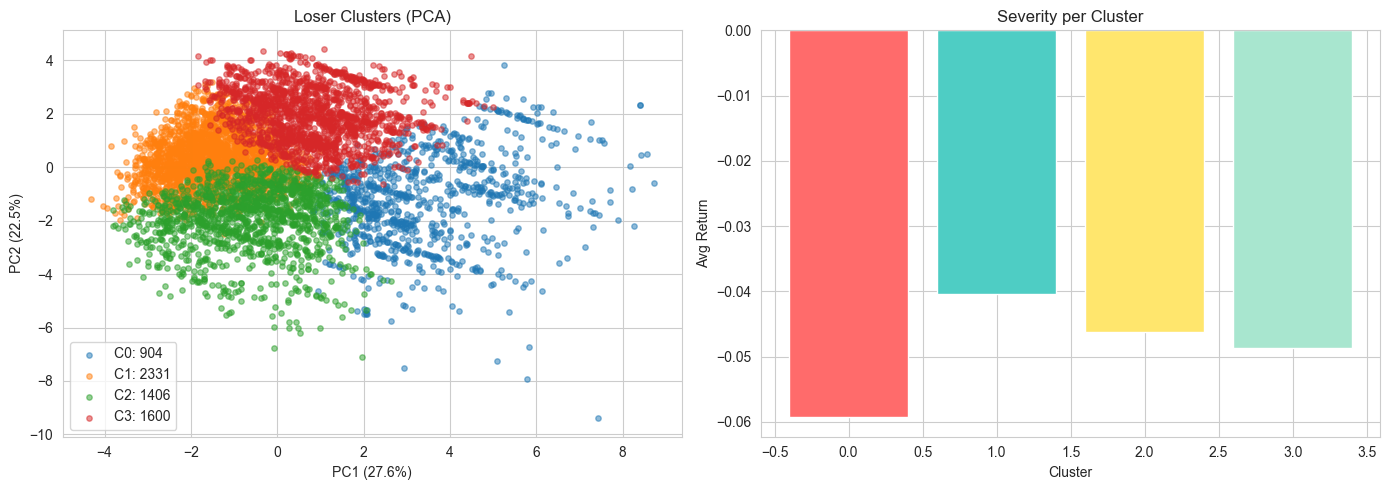

In [44]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

N_CLUSTERS  = 4
top_n       = 15
clust_feats = discrim_df.head(top_n)['feature'].tolist()

loser_data = losers[clust_feats].dropna()
scaler     = StandardScaler()
X_sc       = scaler.fit_transform(loser_data)
pca        = PCA(n_components=2)
X_pca      = pca.fit_transform(X_sc)
km         = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=20)
clusters   = km.fit_predict(X_sc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for k in range(N_CLUSTERS):
    m = clusters==k
    axes[0].scatter(X_pca[m,0], X_pca[m,1], alpha=0.5, s=15, label=f'C{k}: {m.sum()}')
axes[0].set(xlabel=f'PC1 ({pca.explained_variance_ratio_[0]:.1%})',
            ylabel=f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', title='Loser Clusters (PCA)')
axes[0].legend()
avg_ret = [losers.iloc[loser_data.index.get_indexer(loser_data.index)].iloc[clusters==k]['net_return'].mean()
           for k in range(N_CLUSTERS)]
axes[1].bar(range(N_CLUSTERS), avg_ret, color=['#FF6B6B','#4ECDC4','#FFE66D','#A8E6CF'][:N_CLUSTERS])
axes[1].set(xlabel='Cluster', ylabel='Avg Return', title='Severity per Cluster')
plt.tight_layout(); plt.show()

In [45]:
centroids = pd.DataFrame(
    scaler.inverse_transform(km.cluster_centers_),
    columns=clust_feats, index=[f'Cluster {k}' for k in range(N_CLUSTERS)],
)
centroids.loc['Winner mean'] = winners[clust_feats].mean()
print("Cluster centroids vs winner mean:")
print(centroids.round(3).to_string())

overall_std = training_df[clust_feats].std()
print("\nTop distinguishing features per cluster:")
for k in range(N_CLUSTERS):
    diff = (centroids.loc[f'Cluster {k}'] - centroids.loc['Winner mean']) / overall_std
    top5 = diff.abs().sort_values(ascending=False).head(5)
    print(f"\nCluster {k} (n={(clusters==k).sum()}):")
    for feat in top5.index:
        print(f"  {'up' if diff[feat]>0 else 'dn'} {feat}: {diff[feat]:+.2f}sigma")

Cluster centroids vs winner mean:
             vnindex_ret_5d  sym_atr_pct  vnindex_vol_20d  sym_vol_20d  gkyz_sym_raw  gkyz_market_raw  breadth_mcclel_osc  breadth_ad_ratio_pct  breadth_declines  mrs_20d  breadth_advances  breadth_ad_line  gkyz_market_norm  dist_from_52w_high  smf_strength
Cluster 0             0.019        6.325            0.020       72.769        78.309           27.977              26.750                54.588            78.095   -2.717            94.625        -3580.445             0.732              -0.429        -0.347
Cluster 1             0.013        2.506            0.008       27.515        30.764           12.163              14.060                49.742            80.273   -1.257            79.143        -3512.668             0.241              -0.217        -0.109
Cluster 2            -0.003        3.575            0.013       40.496        43.128           18.286             -21.926                31.740           117.040    1.003            53.564    

## 11. VNINDEX Regime Diagnostics

VNINDEX features were pre-computed in §3 — visualization only.

Win rates by regime:
                                             n  win_rate  avg_return
vnindex_above_ema50 vnindex_above_ema200                            
0                   0                     2930    0.4034      0.0622
                    1                     1780    0.3146      0.0425
1                   0                      693    0.2424      0.0344
                    1                     4058    0.2762      0.0221


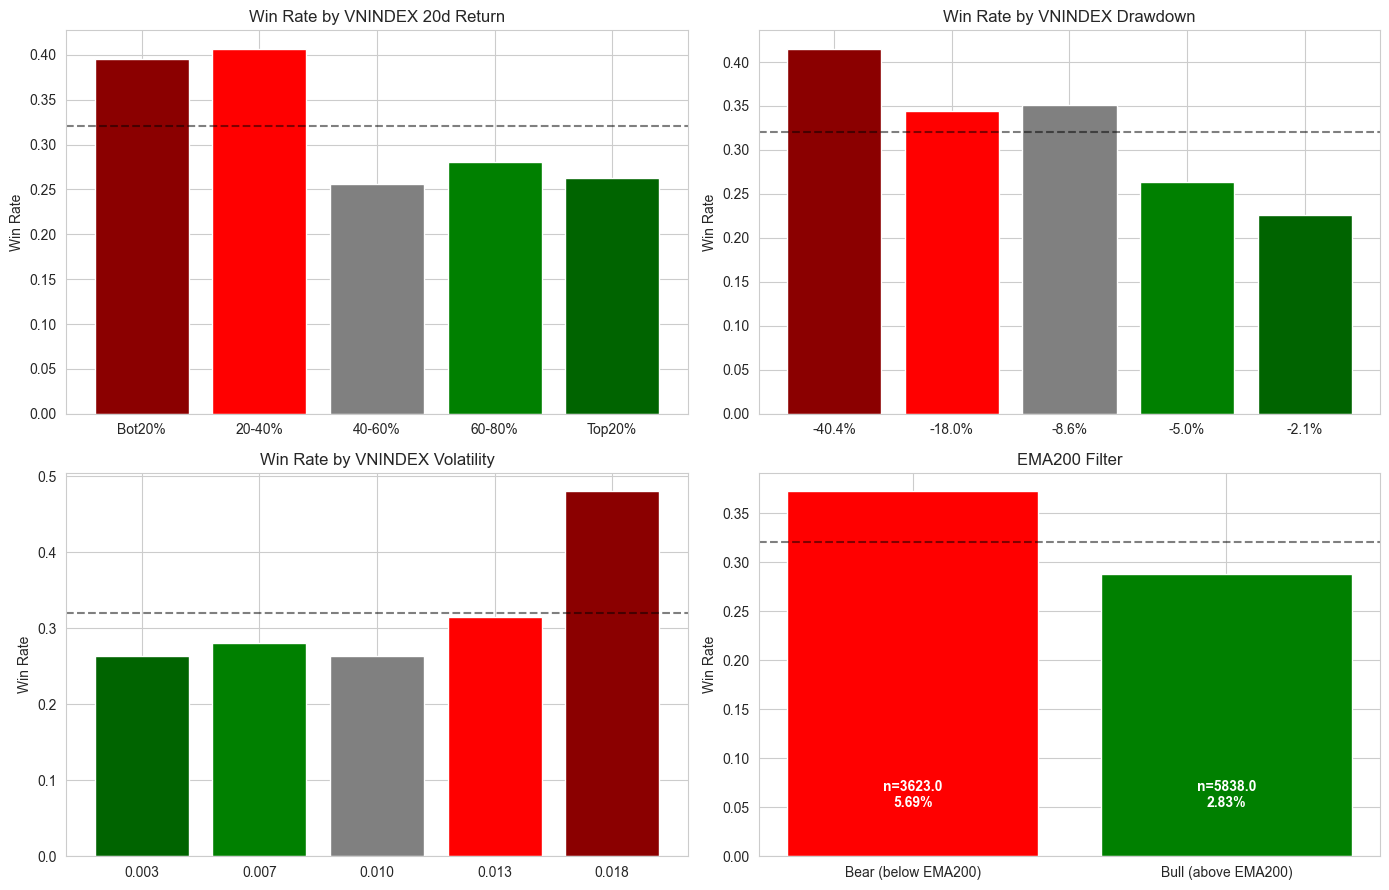

In [46]:
if 'vnindex_above_ema200' not in training_df.columns:
    print("WARNING: VNINDEX features not available")
else:
    print("Win rates by regime:")
    print(training_df.groupby(['vnindex_above_ema50','vnindex_above_ema200']).agg(
        n=('Y','count'), win_rate=('Y','mean'), avg_return=('net_return','mean')
    ).round(4))

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    ax = axes[0,0]
    rb = pd.qcut(training_df['vnindex_ret_20d'].dropna(), 5,
                  labels=['Bot20%','20-40%','40-60%','60-80%','Top20%'])
    training_df['vix_ret_bin'] = rb
    bs = training_df.groupby('vix_ret_bin',observed=True).agg(win_rate=('Y','mean'))
    ax.bar(range(5), bs['win_rate'], color=['darkred','red','gray','green','darkgreen'])
    ax.axhline(training_df['Y'].mean(), color='black', linestyle='--', alpha=0.5)
    ax.set(xticks=range(5), xticklabels=bs.index, ylabel='Win Rate', title='Win Rate by VNINDEX 20d Return')

    ax = axes[0,1]
    db = pd.qcut(training_df['vnindex_drawdown'].dropna(), 5)
    training_df['vix_dd_bin'] = db
    ds = training_df.groupby('vix_dd_bin',observed=True).agg(win_rate=('Y','mean'))
    ax.bar(range(5), ds['win_rate'], color=['darkred','red','gray','green','darkgreen'])
    ax.axhline(training_df['Y'].mean(), color='black', linestyle='--', alpha=0.5)
    ax.set(xticks=range(5), xticklabels=[f'{b.left:.1%}' for b in ds.index],
           ylabel='Win Rate', title='Win Rate by VNINDEX Drawdown')

    ax = axes[1,0]
    vb = pd.qcut(training_df['vnindex_vol_20d'].dropna(), 5)
    training_df['vix_vol_bin'] = vb
    vs = training_df.groupby('vix_vol_bin',observed=True).agg(win_rate=('Y','mean'))
    ax.bar(range(5), vs['win_rate'], color=['darkgreen','green','gray','red','darkred'])
    ax.axhline(training_df['Y'].mean(), color='black', linestyle='--', alpha=0.5)
    ax.set(xticks=range(5), xticklabels=[f'{b.left:.3f}' for b in vs.index],
           ylabel='Win Rate', title='Win Rate by VNINDEX Volatility')

    ax = axes[1,1]
    fs = training_df.groupby('vnindex_above_ema200').agg(
        n=('Y','count'), win_rate=('Y','mean'), avg_return=('net_return','mean'))
    fs.index = ['Bear (below EMA200)','Bull (above EMA200)']
    ax.bar(range(2), fs['win_rate'], color=['red','green'])
    ax.axhline(training_df['Y'].mean(), color='black', linestyle='--', alpha=0.5)
    ax.set(xticks=range(2), xticklabels=fs.index, ylabel='Win Rate', title='EMA200 Filter')
    for i,(_,row) in enumerate(fs.iterrows()):
        ax.text(i,0.05,f"n={row['n']}\n{row['avg_return']:.2%}",
                ha='center',color='white',fontweight='bold',fontsize=10)

    plt.tight_layout(); plt.show()

## 12. Feature Engineering Suggestions

In [47]:
suggestions = []

if 'vnindex_above_ema200' in training_df.columns:
    bwr = training_df[training_df['vnindex_above_ema200']==0]['Y'].mean()
    bul = training_df[training_df['vnindex_above_ema200']==1]['Y'].mean()
    if abs(bul-bwr) > 0.05:
        suggestions.append({'priority':1,'name':'vnindex_trend_regime',
            'reason':f'Bull WR {bul:.1%} vs Bear WR {bwr:.1%}'})

if 'vix_vol_bin' in training_df.columns:
    vwr = training_df.groupby('vix_vol_bin',observed=True)['Y'].mean()
    if vwr.max()-vwr.min() > 0.05:
        suggestions.append({'priority':1,'name':'vnindex_volatility_regime',
            'reason':f'WR spans {vwr.min():.1%}-{vwr.max():.1%} across vol regimes'})

if len(chronic_losers):
    suggestions.append({'priority':1,'name':'symbol_blacklist / rolling_symbol_winrate',
        'reason':f'{len(chronic_losers)} symbols with <35% historical WR'})

if p < 0.05:
    suggestions.append({'priority':2,'name':'day_of_week','reason':'DOW chi2 significant'})

suggestions += [
    {'priority':1,'name':'breakout_quality',
     'reason':'dist_from_52w_high & close_in_range registered — check their Cohen d in section 4'},
    {'priority':2,'name':'cross_sectional_ranks',
     'reason':'RSI/vol/momentum ranks are orthogonal to price-level features'},
    {'priority':1,'name':'strategy_self_assessment',
     'reason':'Rolling WR of last N closed trades predicts near-term regime'},
]
suggestions.sort(key=lambda x: x['priority'])
print("=" * 60, "\nRANKED FEATURE SUGGESTIONS\n", "=" * 60)
for i,s in enumerate(suggestions,1):
    pri = 'HIGH' if s['priority']==1 else 'MED'
    print(f"\n{i}. [{pri}] {s['name']}\n   {s['reason']}")

RANKED FEATURE SUGGESTIONS

1. [HIGH] vnindex_trend_regime
   Bull WR 28.8% vs Bear WR 37.3%

2. [HIGH] vnindex_volatility_regime
   WR spans 26.4%-48.0% across vol regimes

3. [HIGH] symbol_blacklist / rolling_symbol_winrate
   134 symbols with <35% historical WR

4. [HIGH] breakout_quality
   dist_from_52w_high & close_in_range registered — check their Cohen d in section 4

5. [HIGH] strategy_self_assessment
   Rolling WR of last N closed trades predicts near-term regime

6. [MED] day_of_week
   DOW chi2 significant

7. [MED] cross_sectional_ranks
   RSI/vol/momentum ranks are orthogonal to price-level features


## 13. Export Findings

In [48]:
os.makedirs('../reports', exist_ok=True)
ts = datetime.now().strftime('%Y%m%d_%H%M')
report = {
    'autopsy_date':       datetime.now().isoformat(),
    'registered_features': list(FEATURES.keys()),
    'data_summary': {
        'total_trades':       int(len(training_df)),
        'date_range':         [str(training_df['entry_date'].min()), str(training_df['entry_date'].max())],
        'symbols':            int(training_df['symbol'].nunique()),
        'overall_win_rate':   float(training_df['Y'].mean()),
        'overall_avg_return': float(training_df['net_return'].mean()),
    },
    'top_discriminative_features': discrim_df.head(20).to_dict('records'),
    'catastrophic_loss_drivers':   catastrophic_vs_others.head(20).to_dict('records'),
    'chronic_loser_symbols':       chronic_losers['symbol'].tolist() if len(chronic_losers) else [],
    'worst_months':                worst_months[['year_month','win_rate','avg_return']].astype(str).to_dict('records'),
    'feature_suggestions':         suggestions,
}
with open(f'../reports/loser_autopsy_{ts}.json','w') as f:
    json.dump(report, f, indent=2, default=str)
discrim_df.to_csv(f'../reports/discriminative_features_{ts}.csv', index=False)
print(f"  ../reports/loser_autopsy_{ts}.json")
print(f"  ../reports/discriminative_features_{ts}.csv")

  ../reports/loser_autopsy_20260710_2142.json
  ../reports/discriminative_features_20260710_2142.csv


## Next Steps

### Adding a hypothesis
1. Open §3 → "ADD YOUR HYPOTHESIS HERE" cell
2. Add a `@feature("name", "description")` function
3. Re-run §3 apply cell (`_apply_all`) + all cells below
4. Check §4 discrimination plot — does your feature rank in the top 12?
5. Cohen's d > 0.2 → add to meta-labeling feature pipeline

### Validation checklist
- [ ] No look-ahead (only data <= `entry_date`)
- [ ] Cohen's d > 0.2 in this autopsy
- [ ] OOS AUC improves >= 0.005 in meta-labeling notebook
- [ ] Sharpe lift positive in threshold sweep

### When to stop
Re-run each round. When no unmodeled feature has |d| > 0.3, shift focus to risk rules (position sizing, stops) rather than prediction.